# Disaster at St. Himark!: Citizen Science to the Rescue
## Background
St. Himark is a vibrant community located in the Oceanus Sea. Home to the world-renowned St. Himark Museum, beautiful beaches, and the Wilson Forest Nature Preserve, St. Himark is one of the region’s best cities for raising a family and provides employment across a number of industries including the Always Safe Nuclear Power Plant. Well, all that was true before the disastrous earthquake that hits the area during the course of this year’s challenge. Mayor Jordan, city officials, and emergency services are overwhelmed and are desperate for assistance in understanding the true situation on the ground and how best to deploy the limited resources available to this relatively small community.

One of St. Himark’s largest employers is the Always Safe nuclear power plant. The pride of the city, it produces power for St. Himark’s needs and exports the excess to the mainland providing a steady revenue stream. However, the plant was not compliant with international standards when it was constructed and is now aging. As part of its outreach to the broader community, Always Safe agreed to provide funding for a set of carefully calibrated professional radiation monitors at fixed locations throughout the city. Additionally, a group of citizen scientists led by the members of the Himark Science Society started an education initiative to build and deploy lower cost homemade sensors, which people can attach to their cars. The sensors upload data to the web by connecting through the user’s cell phone. The goal of the project was to engage the community and demonstrate that the nuclear plant’s operations were not significantly changing the region’s natural background levels of radiation.

When an earthquake strikes St. Himark, the nuclear power plant suffers damage resulting in a leak of radioactive contamination. Further, a coolant leak sprayed employees’ cars and contaminated them at varying levels. Now, the city’s government and emergency management officials are trying to understand if there is a risk to the public while also responding to other emerging crises related to the earthquake as well as satisfying the public’s concern over radiation.

*Note: reviewing the city description document may be helpful to understanding the landscape and character of the city.*

### Data - *[Download](https://github.com/emmanueliarussi/DataScienceCapstone/raw/master/7_FinalProjects/DisasterStHimarkCitizenScienceRescue/data.zip)*

You will find two data files spanning the entire length of the events (12 am on April 6, 2020 to 11:59 pm on April 10, 2020), containing radiation measurements from mobile and static radiation sensors.  We also provide a set of supporting files. Be prepared for missing and corrupted data, skipped timesteps, and other issues. Both radiation measurements and movements may be affected by conditions in the city.

### Goals
Your task, as supported by data analytics that you apply, is to help St. Himark’s emergency management team combine data from the government-operated stationary monitors with data from citizen-operated mobile sensors to help them better understand conditions in the city and identify likely locations that will require further monitoring, cleanup, or even evacuation. Will data from citizen scientists clarify the situation or make it more uncertain? Use data and visual analytics to develop responses to the questions below.

1. Visualize radiation measurements over time from both static and mobile sensors to identify areas where radiation over background is detected. Characterize changes over time.

2. Use data analytics to represent and analyze uncertainty in the measurement of radiation across the city.
    1. Compare uncertainty of the static sensors to the mobile sensors. What anomalies can you see? Are there sensors that are too uncertain to trust?
    2. Which regions of the city have greater uncertainty of radiation measurement? Use data analytics to explain your rationale.
    3. What effects do you see in the sensor readings after the earthquake and other major events? What effect do these events have on uncertainty?

3. Given the uncertainty you observed in question 2, are the radiation measurements reliable enough to locate areas of concern?
    1. Highlight potential locations of contamination, including the locations of contaminated cars. Should St. Himark officials be worried about contaminated cars moving around the city?
    2. Estimate how many cars may have been contaminated when coolant leaked from the Always Safe plant. Use data analysis of radiation measurements to determine if any have left the area.
    3. Indicated where you would deploy more sensors to improve radiation monitoring in the city. Would you recommend more static sensors or more mobile sensors or both? Use your analysis of radiation measurement uncertainty to justify your recommendation.

4. Summarize the state of radiation measurements at the end of the available period. Use your data analysis approaches to suggest a course of action for the city. Use analytics to compare the static sensor network to the mobile sensor network. What are the strengths and weaknesses of each approach? How do they support each other?

## Deliverables

Please prepare __a single python notebook__ with the answers. However, feel free to use more than a single python file to solve tasks. If necessary, some results may be pre-computed and stored in separate files. Notebooks must clearly explain the answers to each question, supported by evidence derived from the data and visualized using the tools seen in the course. Describe the characteristics of the data you were given as well as your reasoning process leading to each answer. Use the following structure template for the answers notebook:

- project title, task name
- description and data characterization
- answer question 1
- answer question 2
- ...

# Detectando restos de radiación en St Hilmark

Nos poroponemos ir contestando las preguntas solicitadas mientras en paralelo vamos mostrando los datos que le dan soporte a nuestras respuestas.

### Cargo datos

In [1]:
!pip install geoviews jupyter_bokeh  pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 574.7/574.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.2 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [1]:
# =============================================================================
# BIBLIOTECAS ESTÁNDAR DE PYTHON
# =============================================================================
import glob
import os
import shutil
from collections import Counter
import requests
import zipfile

# =============================================================================
# CIENCIA DE DATOS Y CÁLCULO CIENTÍFICO
# =============================================================================
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist

# =============================================================================
# VISUALIZACIÓN (MATPLOTLIB, SEABORN, PLOTLY)
# =============================================================================
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
from matplotlib.figure import Figure


import plotly.graph_objects as go
import seaborn as sns

# =============================================================================
# ESTADÍSTICA Y MODELOS (STATSMODELS)
# =============================================================================
import statsmodels
import statsmodels.api as sm
import statsmodels.graphics.api as smg
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from pykrige.ok import OrdinaryKriging


# =============================================================================
# PROGRESO Y MANEJO DE ARCHIVOS
# =============================================================================
from tqdm import tqdm
import imageio.v2 as imageio

# =============================================================================
# SIG (SISTEMAS DE INFORMACIÓN GEOGRÁFICA) Y VISUALIZACIÓN INTERACTIVA
# =============================================================================
import geopandas as gpd
import geoviews as gv
import holoviews as hv
import panel as pn
import param
from holoviews import opts, dim
from shapely.geometry import Point

import warnings
from bokeh.util.warnings import BokehUserWarning

from IPython.display import display





In [2]:

# URL del archivo ZIP
zip_file_url = "https://github.com/emmanueliarussi/DataScienceCapstone/raw/master/7_FinalProjects/DisasterStHimarkCitizenScienceRescue/data.zip"

# Ruta donde se guardará el archivo ZIP y se descomprimirá
target_directory = "./"
zip_file_name = os.path.join(target_directory, "data.zip")

# Crear el directorio si no existe
os.makedirs(target_directory, exist_ok=True)

print(f"Descargando {zip_file_url}...")
response = requests.get(zip_file_url, stream=True)
response.raise_for_status() # Asegurarse de que la descarga fue exitosa

with open(zip_file_name, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)
print(f"Descarga completada. Archivo guardado en {zip_file_name}")

print(f"Descomprimiendo {zip_file_name} en {target_directory}...")
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(target_directory)
print("Descompresión completada.")


Descargando https://github.com/emmanueliarussi/DataScienceCapstone/raw/master/7_FinalProjects/DisasterStHimarkCitizenScienceRescue/data.zip...
Descarga completada. Archivo guardado en ./data.zip
Descomprimiendo ./data.zip en ./...
Descompresión completada.


In [3]:
# =============================================================================
# CONFIGURACIÓN Y CONSTANTES
# =============================================================================
BASE_PATH = "./data/"
# BASE_PATH ="/content/drive/MyDrive/data_viz/data/"
SHAPEFILE_PATH = BASE_PATH + "StHimarkNeighborhoodShapefile"

# Coordenadas de los 8 hospitales (extraídas de tu diccionario)
HOSPITAL_COORDS = {
    'lon': [-119.959400, -119.915900, -119.909520, -119.904300,
            -119.883420, -119.855580, -119.828610, -119.744800],
    'lat': [0.180960, 0.153120, 0.151090, 0.121800,
            0.134560, 0.182990, 0.041470, 0.065250]
}
NUCLEAR_PLANT_COORD = (-119.784825, 0.162679)

# =============================================================================
# FUNCIONES AUXILIARES (DRY - No repetir lógica)
# =============================================================================
def create_gdf_from_coords(df, lat_col='Lat', lon_col='Long', crs="EPSG:4326"):
    """
    Convierte un DataFrame con columnas de latitud/longitud en un GeoDataFrame.
    """
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    return gpd.GeoDataFrame(df, geometry=geometry, crs=crs)

# =============================================================================
# 1. CARGA DE DATOS
# =============================================================================

# --- 1.1 Shapefile de vecindarios ---
try:
    neighborhoods = gpd.read_file(SHAPEFILE_PATH).to_crs(epsg=4326)
    print("✅ Shapefile de vecindarios cargado correctamente.")
except Exception as e:
    print(f"❌ Error al cargar el shapefile: {e}")
    neighborhoods = None

# --- 1.2 Sensores fijos (ubicaciones + lecturas) ---
def load_static_sensors(base_path):
    # Ubicaciones
    locs = pd.read_csv(base_path + "/StaticSensorLocations.csv")
    locs['Sensor-id'] = locs['Sensor-id'].astype(int)
    locs_gdf = create_gdf_from_coords(locs)

    # Lecturas
    readings = pd.read_csv(base_path + "/StaticSensorReadings.csv")
    readings['Timestamp'] = pd.to_datetime(readings['Timestamp'])

    print("✅ Sensores fijos cargados correctamente.")
    return locs_gdf, readings

static_sensors, static_readings = load_static_sensors(BASE_PATH)

# --- 1.3 Sensores móviles (lecturas con ubicación) ---
def load_mobile_sensors(base_path):
    df = pd.read_csv(base_path + "/MobileSensorReadings.csv")

    # Limpieza y conversión de tipos
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Sensor-id'] = df['Sensor-id'].astype(int) + 100  # Offset para distinguirlos de fijos
    df['Lat'] = df['Lat'].astype(float)
    df['Long'] = df['Long'].astype(float)
    df['Value'] = df['Value'].astype(float)

    # Eliminar valor atípico (máximo global, asumido como error)
    max_val = df['Value'].max()
    df = df[df['Value'] != max_val].reset_index(drop=True)
    print(f"⚠️ Eliminado registro con valor {max_val} (considerado erróneo).")

    # Convertir a GeoDataFrame y ordenar
    gdf = create_gdf_from_coords(df)
    gdf = gdf.sort_values(by='Timestamp').reset_index(drop=True)

    print("✅ Sensores móviles cargados correctamente.")
    return gdf

mobile_sensors = load_mobile_sensors(BASE_PATH)

# =============================================================================
# 2. COMBINACIÓN DE SENSORES (FIJOS + MÓVILES)
# =============================================================================
def combine_sensors(static_readings, static_gdf, mobile_gdf):
    # --- Fusionar lecturas estáticas con sus coordenadas ---
    static_merged = static_readings.merge(
        static_gdf[['Sensor-id', 'Lat', 'Long', 'geometry']],
        on="Sensor-id"
    )
    static_merged['User-id'] = 'Fijo'

    # --- Preparar datos móviles (ya tienen geometría) ---
    mobile_merged = mobile_gdf.copy()
    mobile_merged['User-id'] = 'Movil'

    # --- Unificar columnas y concatenar ---
    cols = ['Timestamp', 'Sensor-id', 'Value', 'Long', 'Lat', 'geometry', 'User-id']
    combined = pd.concat([static_merged[cols], mobile_merged[cols]], axis=0, ignore_index=True)

    print(f"✅ Datos combinados: {len(combined)} registros totales.")
    return combined

df_sensores = combine_sensors(static_readings, static_sensors, mobile_sensors)


✅ Shapefile de vecindarios cargado correctamente.
✅ Sensores fijos cargados correctamente.
⚠️ Eliminado registro con valor 57345.20030135344 (considerado erróneo).
✅ Sensores móviles cargados correctamente.
✅ Datos combinados: 4059710 registros totales.


In [4]:
# =============================================================================
# 2.5 ASIGNACIÓN DE COLORES ÚNICOS POR SENSOR
# =============================================================================
def assign_sensor_colors(sensor_ids, cmap_name='gist_ncar', shuffle=False, seed=42):
    """
    Asigna un color único a cada sensor.

    Parámetros:
    -----------
    sensor_ids : list/int
        Lista de IDs de sensores únicos.
    cmap_name : str
        Nombre del colormap de matplotlib (ej: 'gist_ncar', 'tab20', 'hsv').
    shuffle : bool
        Si True, mezcla los colores para evitar agrupaciones similares.
    seed : int
        Semilla para reproducibilidad al mezclar.

    Retorna:
    --------
    dict : {sensor_id: color_RGBA}
    """
    unique_ids = sorted(sensor_ids)
    cmap = plt.get_cmap(cmap_name)
    n = len(unique_ids)
    colors = [cmap(i / n) for i in range(n)]

    if shuffle:
        import random
        random.seed(seed)
        random.shuffle(colors)

    return {sensor: colors[i] for i, sensor in enumerate(unique_ids)}

# --- Asignar colores a todos los sensores (fijos y móviles) ---
sensor_ids = sorted(df_sensores['Sensor-id'].unique())
color_por_sensor = assign_sensor_colors(
    sensor_ids,
    cmap_name='gist_ncar',   # Cambia a 'tab20' si tienes <=20 sensores
    shuffle=True             # Mezcla para mejor contraste
)

# Añadir columna 'color' al DataFrame para uso rápido
df_sensores['color'] = df_sensores['Sensor-id'].map(color_por_sensor)

print(f"✅ Asignados {len(color_por_sensor)} colores únicos para sensores.")
print(f"Ejemplo: Sensor {list(color_por_sensor.keys())[0]} -> {color_por_sensor[list(color_por_sensor.keys())[0]]}")

# =============================================================================
# SWATCH: VISUALIZACIÓN DE LA PALETA DE COLORES ASIGNADA
# =============================================================================
def show_color_palette(color_dict):
    """
    Muestra una muestra visual (swatch) de la paleta de colores asignada.
    Cada barra representa un sensor y muestra su ID y el color.

    Parámetros:
    -----------
    color_dict : dict
        Diccionario con {sensor_id: color_RGBA}
    figsize : tuple
        Tamaño de la figura (ancho, alto)
    """

    n = len(color_dict)
    if n == 0:
        print("No hay colores para mostrar.")
        return

    figsize=(2, max(4, len(color_dict)//8))

    fig, ax = plt.subplots(figsize=figsize)
    ids = sorted(color_dict.keys())
    colors = [color_dict[id_] for id_ in ids]

    # Dibujar barras horizontales
    y_pos = range(n)
    ax.barh(y_pos, [1]*n, color=colors, edgecolor='none', height=0.8, alpha=0.8)

    # Etiquetas con IDs
    ax.set_yticks(y_pos)
    ax.set_yticklabels([str(id_) for id_ in ids], fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.set_xlabel('Color')
    ax.set_title(f'Paleta de colores para {n} sensores (colormap: gist_ncar, shuffle=True)', fontsize=14)

    # Quitar bordes
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False)

    plt.tight_layout()
    plt.show()

# --- Mostrar la paleta de colores ---
# show_color_palette(color_por_sensor)

✅ Asignados 59 colores únicos para sensores.
Ejemplo: Sensor 1 -> (np.float64(1.0), np.float64(9.323729491583777e-06), np.float64(0.13831931854709198), np.float64(1.0))


In [ ]:
def plot_map(neighborhoods, sensors_gdf, hospital_coords, nuclear_coord):
    """
    Dibuja el mapa de St. Himark resaltando:
    - Vecindarios (fondo)
    - Hospitales (marcadores rojos)
    - Planta Nuclear (marcador amarillo con ☢️)
    - ID de cada sensor fijo (texto con fondo)
    """
    fig, ax = plt.subplots(1, 1, figsize=(13, 7))

    # --- Fondo: Vecindarios ---
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax, cmap="tab20", alpha=0.4, edgecolor='black', linewidth=0.8)
        neighborhoods.boundary.plot(ax=ax, color='black', linewidth=0.5)

    # --- 1. Hospitales (cruces rojas con etiqueta) ---
    ax.scatter(hospital_coords['lon'], hospital_coords['lat'],
               marker='P', s=200, color='red', edgecolor='darkred',
               linewidth=1, zorder=5, label='Hospitales')

    # --- 2. Planta Nuclear (marcador personalizado) ---
    ax.scatter(nuclear_coord[0], nuclear_coord[1],
               marker='o', s=200, color='gold', edgecolor='orange',
               linewidth=2, zorder=6, label='Planta Nuclear')
    # Añadir el emoji encima (más visible)
    ax.text(nuclear_coord[0], nuclear_coord[1], '☢️',
            fontsize=15, ha='center', va='center', zorder=7,
            bbox=dict(facecolor='yellow', edgecolor='none', alpha=0.8, pad=1, boxstyle='round,pad=0.1'))

    # --- 3. Sensores fijos (IDs sobre el mapa) ---
    for _, row in sensors_gdf.iterrows():
        x, y = row.geometry.x, row.geometry.y
        ax.text(x, y, str(row['Sensor-id']),
                fontsize=10, ha='center', va='center', zorder=10,
                bbox=dict(facecolor='white', edgecolor='gray',
                          alpha=0.85, pad=1, boxstyle='round,pad=0.2'))

    # --- Leyenda y configuración ---
    ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
    ax.set_axis_off()
    ax.set_title("St. Himark - Sensores fijos y puntos de interés",
                 fontsize=16, pad=20, weight='bold')

    plt.tight_layout()
    plt.show()
    plt.close()
    return None

# plot_map(neighborhoods, static_sensors, HOSPITAL_COORDS, NUCLEAR_PLANT_COORD)

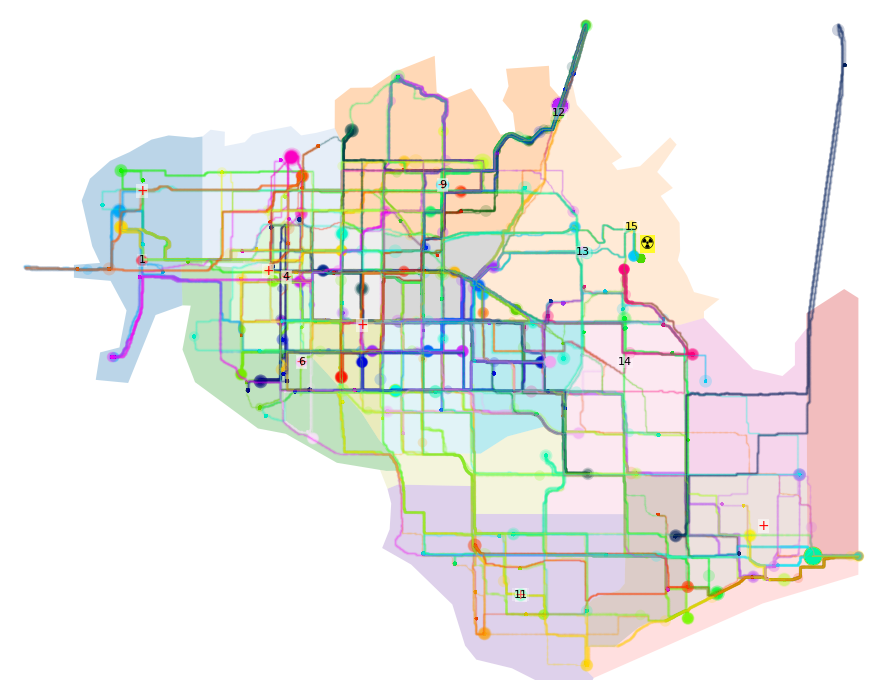

In [5]:

def plot_recorridos(df, color_por_sensor):
    vmin, vmax = df['Value'].min(), df['Value'].max()
    x_max, x_min, y_max, y_min = df.Long.max(), df.Long.min(), df.Lat.max(), df.Lat.min()
    margen = 0.005
    x_min -= margen
    x_max += margen
    y_min -= margen
    y_max += margen


    fig, ax = plt.subplots(figsize=(13, 7))

    # FIJAR LÍMITES CONSTANTES PARA TODAS LAS VENTANAS
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    neighborhoods.plot(cmap="tab20", alpha=0.3, ax=ax)

    # Normalizar los valores de 'Value' para que los tamaños estén en un rango visible
    # Por ejemplo, entre 5 y 50 puntos de diámetro (s es área, por lo que diámetro ~ sqrt(s))
    # Podemos usar un mapeo lineal o usar los valores directamente.
    vmin, vmax = df['Value'].min(), df['Value'].max()
    # Evitar división por cero si vmax == vmin
    if vmax == vmin:
        sizes = 20 * np.ones(len(df))
    else:
        # Normalizar y escalar a área entre 20 y 200 (píxeles cuadrados)
        norm = (df['Value'] - vmin) / (vmax - vmin)
        sizes = 1 + 200 * norm  # área entre 20 y 170

    # Parámetros para alpha: mayor visibilidad para valores altos
    # Definimos alpha de 0.2 (bajo) a 0.9 (alto) según umbral >200
    alphas = np.where(df['Value'] > 80, 0.2, 0.05)  # puedes ajustar valores intermedios


    # Dibujar líneas (sin marcadores) y luego puntos con tamaño variable
    for sensor_id, group in df.groupby('Sensor-id'):
        color_fijo = color_por_sensor[sensor_id]
        # Ordenar por Timestamp
        group = group.sort_values('Timestamp')
        # Línea
        ax.plot(group['Long'], group['Lat'], linestyle='-', alpha=0.3, color=color_fijo, linewidth=0.5)
        # Puntos con scatter (tamaño variable)
        # Extraer tamaños para este grupo
        idx = group.index
        group_sizes = sizes[group.index]  # si df tiene índice único


        ax.scatter(group['Long'], group['Lat'], s=group_sizes, color=color_fijo,
                   alpha=alphas[idx], label=f'Sensor {sensor_id}', edgecolors='none')


    lista_hospitales = { 'x_h':[-119.959400, -119.915900, -119.909520, -119.904300, -119.883420, -119.855580, -119.828610, -119.744800],
                         'y_h':[0.180960, 0.153120, 0.151090, 0.121800, 0.134560, 0.182990, 0.041470, 0.065250]}
    for hosp in range(8):
        ax.text(lista_hospitales['x_h'][hosp], lista_hospitales['y_h'][hosp], "+", fontsize=10, ha='center', va='center', color='red',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=0))

    ax.text(-119.784825, 0.162679, "☢️", fontsize=12, ha='center', va='center',
           bbox=dict(facecolor='yellow', edgecolor='none', alpha=0.8, pad=0))

    # Dibujar cada sensor fijo con su ID como texto
    for sensor_fijo in df_sensores[df_sensores['User-id'] == 'Fijo']['Sensor-id'].unique():
        x=df_sensores[df_sensores['Sensor-id'] == sensor_fijo]['Long'].head(1).iloc[0]
        y=df_sensores[df_sensores['Sensor-id'] == sensor_fijo]['Lat'].head(1).iloc[0]

        ax.text(x, y, str(sensor_fijo),
                fontsize=8, ha='center', va='center',
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.3, pad=1))

    ax.set_axis_off()

    # ax.set_title('Trayectorias de sensores - diámetro proporcional a Value')
    ax.grid(False) #, linestyle='--', alpha=0.5)
    # Si hay muchos sensores, la leyenda puede ser enorme; se puede omitir o poner fuera
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    fig.savefig('mapa_sensores_datos.png', dpi=150, bbox_inches='tight')
    plt.close

plot_recorridos(df_sensores, color_por_sensor)

## 0. description and data characterization


In [ ]:
# =============================================================================
# FILTRADO Y NORMALIZACIÓN (igual que antes)
# =============================================================================
df_filtrado = df_sensores[df_sensores['Value'] >= 50].copy()

# Normalizar Timestamp a [0, 1] y luego escalar a 5 (para que el eje sea comparable)
t_num = df_filtrado['Timestamp'].astype('int64') // 10**9
df_filtrado['Timestamp_norm'] = (t_num - t_num.min()) / (t_num.max() - t_num.min()) * 4

# Normalizar Value (solo para el primer gráfico, el segundo mostrará el valor real)
min_val = df_filtrado['Value'].min()
max_val = df_filtrado['Value'].max()
df_filtrado['Value_norm'] = (df_filtrado['Value'] - min_val) / (max_val - min_val) * 5


# =============================================================================
# FIGURA CON DOS SUBPLOTS LADO A LADO
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Tiempo normalizado vs Sensor ---
sns.stripplot(data=df_filtrado, x='Sensor-id', y='Timestamp_norm',
              jitter=True, alpha=0.4, size=3, ax=ax1)
ax1.set_title('Distribución temporal (normalizada)', fontsize=12, weight='bold')
ax1.set_xlabel('ID del Sensor', fontsize=10)
ax1.set_ylabel('Timestamp normalizado (0-4)', fontsize=10)
ax1.tick_params(axis='x', rotation=90)  # Rotar etiquetas si hay muchos sensores

# --- Gráfico 2: Valor real vs Sensor ---
sns.stripplot(data=df_filtrado, x='Sensor-id', y='Value',
              jitter=True, alpha=0.4, size=4, ax=ax2)
ax2.set_title('Distribución de valores de radiación', fontsize=12, weight='bold')
ax2.set_xlabel('ID del Sensor', fontsize=10)
ax2.set_ylabel('Valor (cpm)', fontsize=10)
ax2.tick_params(axis='x', rotation=90)

# Ajustar el espaciado para que no se solapen
plt.tight_layout()
plt.show()
plt.close()

Filtro previo de valores bajo el 3r cuartil. umbral=36.0


Column
    [0] Markdown(str)
    [1] Row
        [0] FloatSlider(end=140, label='Umbral de filtro (..., name='Umbral de filtro (..., start=40, step=10, value=40, width=400)
        [1] Spacer(width=50)
    [2] Matplotlib(Figure, dpi=100, tight=True)
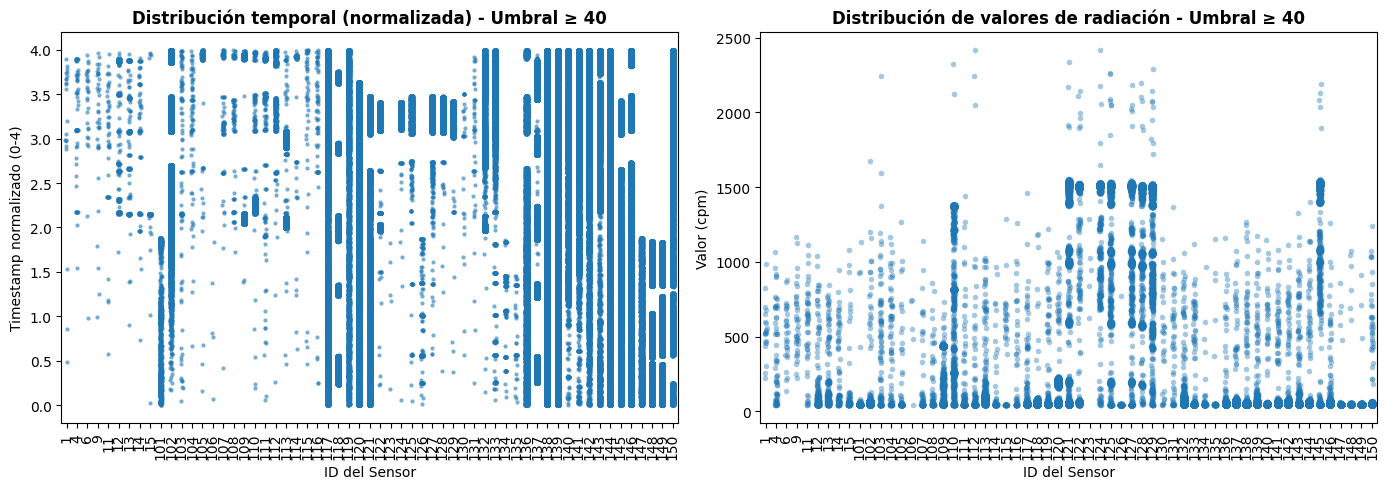

In [11]:
pn.extension()
# --- Función que genera los gráficos según el umbral ---
def plot_panel(df_sensores):

    def plot_interactive(threshold):
        # Filtrar datos
        df_filt = df_sensores[df_sensores['Value'] >= threshold].copy()

        # Si no hay datos, mostrar un mensaje y devolver figura vacía
        if len(df_filt) == 0:
            fig, ax = plt.subplots(1, 2, figsize=(14, 5))
            ax[0].text(0.5, 0.5, f'No hay lecturas con Value >= {threshold}',
                       ha='center', va='center', transform=ax[0].transAxes)
            ax[1].text(0.5, 0.5, f'No hay lecturas con Value >= {threshold}',
                       ha='center', va='center', transform=ax[1].transAxes)
            plt.close()  # Para evitar mostrar una figura vacía extra
            return fig

        # Normalizar Timestamp (escalado a 4 para el eje Y)
        t_num = df_filt['Timestamp'].astype('int64') // 10**9
        t_min = t_num.min()
        t_max = t_num.max()
        df_filt['Timestamp_norm'] = (t_num - t_min) / (t_max - t_min) * 4 if t_max > t_min else 0

        # Normalizar Value (escalado a 5) - solo para referencia, no se usa en este plot
        # pero lo dejamos por si se necesita
        min_val = df_filt['Value'].min()
        max_val = df_filt['Value'].max()
        df_filt['Value_norm'] = (df_filt['Value'] - min_val) / (max_val - min_val) * 5 if max_val > min_val else 0

        # Obtener paleta de colores para los sensores presentes
        sensors_in_filt = df_filt['Sensor-id'].unique()
        palette_dict = {s: color_por_sensor.get(s, 'gray') for s in sensors_in_filt}

        # Crear figura con dos subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Gráfico 1: Tiempo normalizado vs Sensor
        sns.stripplot(data=df_filt, x='Sensor-id', y='Timestamp_norm',
                      jitter=True, alpha=0.6, size=3, ax=ax1)
        ax1.set_title(f'Distribución temporal (normalizada) - Umbral ≥ {threshold}', fontsize=12, weight='bold')
        ax1.set_xlabel('ID del Sensor', fontsize=10)
        ax1.set_ylabel('Timestamp normalizado (0-4)', fontsize=10)
        ax1.tick_params(axis='x', rotation=90)

        # Gráfico 2: Valor real vs Sensor
        sns.stripplot(data=df_filt, x='Sensor-id', y='Value',
                      jitter=True, alpha=0.4, size=4, ax=ax2)
        ax2.set_title(f'Distribución de valores de radiación - Umbral ≥ {threshold}', fontsize=12, weight='bold')
        ax2.set_xlabel('ID del Sensor', fontsize=10)
        ax2.set_ylabel('Valor (cpm)', fontsize=10)
        ax2.tick_params(axis='x', rotation=90)

        plt.tight_layout()
        plt.close()  # Para evitar duplicados en Panel
        return fig

    # --- Crear el slider ---
    # Rango dinámico: desde 0 hasta el máximo de 'Value' (redondeado hacia arriba)
    max_val = df_sensores['Value'].max()
    slider = pn.widgets.FloatSlider(
        name='Umbral de filtro (Value ≥ )',
        start=40,
        end=140, #int(max_val),
        step=10,          # Ajusta según precisión deseada
        value=40,        # Valor inicial
        width=400
    )

    # --- Vincular el slider con la función de gráfico ---
    interactive_plot = pn.bind(plot_interactive, threshold=slider)

    # --- Crear el dashboard ---
    dashboard = pn.Column(
        pn.pane.Markdown("## Filtro interactivo de lecturas de radiación"),
        pn.Row(slider, pn.Spacer(width=50)),  # Espaciado opcional
        pn.pane.Matplotlib(interactive_plot, dpi=100, tight=True)
    )

    # --- Mostrar el dashboard en el notebook ---
    return dashboard

# Primer filtro para
df_sensores_4to_quantil = df_sensores[df_sensores['Value'] > df_sensores.Value.quantile(0.75)].copy()
print(f'Filtro previo de valores bajo el 3r cuartil. umbral={df_sensores.Value.quantile(0.75)}')

display(plot_panel(df_sensores_4to_quantil))

In [14]:
# Ignorar advertencias molestas de Bokeh
warnings.filterwarnings("ignore", category=BokehUserWarning)

pn.extension()

def plot_panel(df_sensores):
    # Asegurar ordenamiento temporal para el análisis de consecutivos
    df_sorted_base = df_sensores.sort_values(['Sensor-id', 'Timestamp']).copy()

    def plot_interactive(threshold, filter_consecutivos, min_consecutivos):
        df_filt = df_sorted_base.copy()
        df_filt['es_elevado'] = df_filt['Value'] >= threshold

        if filter_consecutivos:
            df_filt['bloque_id'] = (df_filt['es_elevado'] != df_filt['es_elevado'].shift()).cumsum()
            df_altos = df_filt[df_filt['es_elevado']]

            if len(df_altos) > 0:
                conteos_bloque = df_altos.groupby(['Sensor-id', 'bloque_id']).size().reset_index(name='conteo')
                bloques_anomalos = conteos_bloque[conteos_bloque['conteo'] >= min_consecutivos]
                df_filt = df_altos.merge(bloques_anomalos[['Sensor-id', 'bloque_id']], on=['Sensor-id', 'bloque_id'])
            else:
                df_filt = pd.DataFrame(columns=df_filt.columns)
        else:
            df_filt = df_filt[df_filt['es_elevado']].copy()

        # --- Matplotlib (1 solo gráfico con proporciones balanceadas) ---
        fig = Figure(figsize=(6, 3.3))
        ax = fig.add_subplot(111)

        # Validación de datos vacíos
        if len(df_filt) == 0:
            msg = f'No hay lecturas que cumplan los criterios (Umbral >= {threshold})'
            if filter_consecutivos:
                msg += f'\ny con al menos {min_consecutivos} consecutivas.'

            ax.text(0.5, 0.5, msg, ha='center', va='center', transform=ax.transAxes, fontsize=10)
            fig.tight_layout()
            return fig

        # Normalización de Timestamp
        t_num = df_filt['Timestamp'].astype('int64') // 10**9
        t_min = t_num.min()
        t_max = t_num.max()
        df_filt['Timestamp_norm'] = (t_num - t_min) / (t_max - t_min) * 4 if t_max > t_min else 0

        # Gráfico: Tiempo normalizado vs Sensor
        sns.stripplot(data=df_filt, x='Sensor-id', y='Timestamp_norm',
                      jitter=True, alpha=0.6, size=3, ax=ax)

        ax.set_title(f'Distribución temporal (normalizada) - Umbral ≥ {threshold}', fontsize=10, weight='bold')
        ax.set_xlabel('ID del Sensor', fontsize=8)
        ax.set_ylabel('Timestamp normalizado (0-4)', fontsize=8)
        ax.tick_params(axis='x', rotation=90, labelsize=6)

        fig.tight_layout()
        return fig

    # --- WIDGETS ---
    max_val = df_sensores['Value'].max()

    slider_umbral = pn.widgets.FloatSlider(
        name='Umbral de filtro (Value ≥)',
        start=40,
        end=120,
        step=10,
        value=50,
        width=300
    )

    chk_consecutivos = pn.widgets.Checkbox(
        name='Filtrado picos aislados',
        value=False
    )

    # Vincular los widgets con la función de gráfico (fijamos consecutivos en 2)
    interactive_plot = pn.bind(
        plot_interactive,
        threshold=slider_umbral,
        filter_consecutivos=chk_consecutivos,
        min_consecutivos=2
    )

    # --- Estructura del Dashboard ---
    dashboard = pn.Column(
        # pn.pane.Markdown("## 🎚️ Filtro interactivo de lecturas de radiación"),
        pn.pane.Matplotlib(interactive_plot, dpi=150, tight=True),
        pn.Row(slider_umbral, chk_consecutivos)
    )

    return dashboard

# Generar el dashboard
df_sensores_4to_quantil = df_sensores[df_sensores['Value'] > df_sensores.Value.quantile(0.75)].copy()
dashboard_final = plot_panel(df_sensores_4to_quantil)

# # --- EXPORTAR A HTML ---
dashboard_final.save(
    'dashboard_radiacion.html',
    embed=True,
    max_states=50,
    max_opts=15
)

Column
    [0] Matplotlib(Figure, dpi=150, tight=True)
    [1] Row
        [0] FloatSlider(end=120, label='Umbral de filtro (..., name='Umbral de filtro (..., start=40, step=10, value=50, width=300)
        [1] Checkbox(label='Filtrar solo v..., name='Filtrar solo v...)
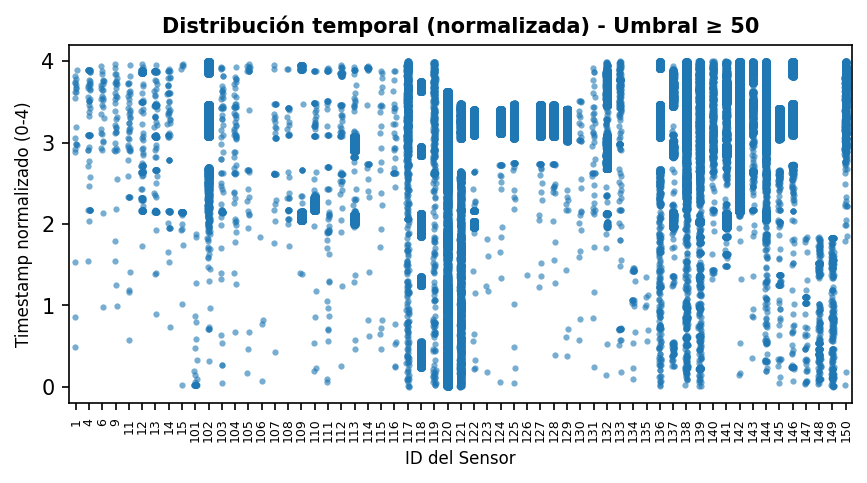

In [13]:
warnings.filterwarnings("ignore", category=BokehUserWarning)
pn.extension()
display(dashboard_final)

## 1. Visualize radiation measurements.
Visualize radiation measurements over time from both static and mobile sensors to identify areas where radiation over background is detected. Characterize changes over time.

### funciones

In [15]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def plot_recorridos_3d_plotly_simple(df, color_por_sensor=color_por_sensor, umbral=30, neighborhoods=neighborhoods, save_html=False):
    # --- 1. Preparar datos base ---
    df = df.copy()

    # Calcular rango temporal
    t_min = df['Timestamp'].min()
    t_max = df['Timestamp'].max()

    df['timestamp_sec'] = (df['Timestamp'] - t_min).dt.total_seconds()
    z_range = df['timestamp_sec'].max() - df['timestamp_sec'].min()
    lat_range = df['Lat'].max() - df['Lat'].min()
    scale = (lat_range / z_range * 1) if (z_range > 0 and lat_range > 0) else 0
    df['z'] = df['timestamp_sec'] * scale
    z_min = df['z'].min()

    # Función para convertir cualquier timestamp a su coordenada Z correspondiente
    def datetime_to_z(dt):
        if dt < t_min: return 0
        return (dt - t_min).total_seconds() * scale

    # Tamaños basados en Value
    vmin, vmax = df['Value'].min(), df['Value'].max()
    def calc_sizes(values):
        if vmax > vmin:
            norm = (values - vmin) / (vmax - vmin)
        else:
            norm = 0.5
        return 2 + 15 * norm

    # --- 2. Precomputar los dos DataFrames (Con Ruido y Filtrado Sin Ruido) ---
    df_con_ruido = df[df['Value'] >= umbral].copy()
    df_con_ruido['size_calc'] = calc_sizes(df_con_ruido['Value'])

    # Lógica de bloques consecutivos (Sin Ruido)
    threshold = umbral
    min_consecutivos = 2

    df_sorted_base = df.sort_values(['Sensor-id', 'Timestamp']).copy()
    df_sorted_base['es_elevado'] = df_sorted_base['Value'] >= threshold
    df_sorted_base['bloque_id'] = (df_sorted_base['es_elevado'] != df_sorted_base['es_elevado'].shift()).cumsum()
    df_altos = df_sorted_base[df_sorted_base['es_elevado']]

    if len(df_altos) > 0:
        conteos_bloque = df_altos.groupby(['Sensor-id', 'bloque_id']).size().reset_index(name='conteo')
        bloques_anomalos = conteos_bloque[conteos_bloque['conteo'] >= min_consecutivos]
        df_sin_ruido = df_altos.merge(bloques_anomalos[['Sensor-id', 'bloque_id']], on=['Sensor-id', 'bloque_id'])
    else:
        df_sin_ruido = pd.DataFrame(columns=df_sorted_base.columns)

    df_sin_ruido['size_calc'] = calc_sizes(df_sin_ruido['Value'])

    # --- Auxiliar de Colores ---
    def get_plotly_color(matplotlib_color_tuple):
        r, g, b = [int(c * 255) for c in matplotlib_color_tuple[:3]]
        return f'rgb({r}, {g}, {b})'

    # --- 3. Construir la Figura Agregando Trazas ---
    fig = go.Figure()

    trazas_con_ruido_indices = []
    trazas_sin_ruido_indices = []
    idx_actual = 0

    # Agregar trazas "Con Ruido"
    for sensor_id, group in df_con_ruido.groupby('Sensor-id'):
        base_color_tuple = color_por_sensor.get(sensor_id, (0.5, 0.5, 0.5, 1.0))
        plotly_color = get_plotly_color(base_color_tuple)
        group = group.sort_values('Timestamp')

        hover_text = ("Sensor: " + str(sensor_id) + "<br>Tiempo: " +
                      group['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S') + "<br>Valor: " + group['Value'].astype(str))

        fig.add_trace(go.Scatter3d(
            x=group['Long'], y=group['Lat'], z=group['z'],
            mode='markers',
            marker=dict(size=group['size_calc'], color=plotly_color, line=dict(width=0)),
            opacity=0.2, name=f'Sensor {sensor_id}',
            text=hover_text, hoverinfo='text', visible=True
        ))
        trazas_con_ruido_indices.append(idx_actual)
        idx_actual += 1

    # Agregar trazas "Sin Ruido"
    for sensor_id, group in df_sin_ruido.groupby('Sensor-id'):
        base_color_tuple = color_por_sensor.get(sensor_id, (0.5, 0.5, 0.5, 1.0))
        plotly_color = get_plotly_color(base_color_tuple)
        group = group.sort_values('Timestamp')

        hover_text = ("Sensor: " + str(sensor_id) + "<br>Tiempo: " +
                      group['Timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S') + "<br>Valor: " + group['Value'].astype(str))

        fig.add_trace(go.Scatter3d(
            x=group['Long'], y=group['Lat'], z=group['z'],
            mode='markers',
            marker=dict(size=group['size_calc'], color=plotly_color, line=dict(width=0)),
            opacity=0.2, name=f'Sensor {sensor_id} (Filtrado)',
            text=hover_text, hoverinfo='text', visible=False
        ))
        trazas_sin_ruido_indices.append(idx_actual)
        idx_actual += 1

    # --- 4. Vecindarios ---
    cant_trazas_vecindarios = 0
    if neighborhoods is not None:
        for geom in neighborhoods.geometry:
            if geom.geom_type == 'Polygon':
                x, y = geom.exterior.xy
                fig.add_trace(go.Scatter3d(
                    x=list(x), y=list(y), z=[z_min] * len(x),
                    mode='lines', line=dict(color='gray', width=2),
                    showlegend=False, hoverinfo='skip', opacity=0.3
                ))
                cant_trazas_vecindarios += 1

    idx_vecindarios_start = idx_actual
    idx_actual += cant_trazas_vecindarios

    # --- 5. Marcadores Fijos ---
    fixed_x=[-119.784825]
    fixed_y=[0.162679]
    fixed_z=[0]
    fixed_labels=['☢️'] # Mantenemos el emoji del reactor por claridad, pero quitamos el resto de los textos

    for sensor_fijo in df_sensores[df_sensores['User-id'] == 'Fijo']['Sensor-id'].unique():
        fixed_x.append(df_sensores[df_sensores['Sensor-id'] == sensor_fijo]['Long'].head(1).iloc[0])
        fixed_y.append(df_sensores[df_sensores['Sensor-id'] == sensor_fijo]['Lat'].head(1).iloc[0])
        fixed_z.append(0)
        fixed_labels.append(str(sensor_fijo))

    fig.add_trace(go.Scatter3d(
        x=fixed_x, y=fixed_y, z=fixed_z,
        mode='text', text=fixed_labels,
        textposition='middle center', textfont=dict(size=10, color='black'),
        marker=dict(size=4, color='black', symbol='square'),
        name='Marcadores Fijos'
    ))
    idx_marcadores_fijos = idx_actual
    idx_actual += 1



    # --- 6. Creación del Plano Temporal (Inicialmente OCULTO) ---
    x_grid = np.linspace(df['Long'].min(), df['Long'].max(), 5)
    y_grid = np.linspace(df['Lat'].min(), df['Lat'].max(), 5)
    x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)
    z_mesh_init = np.ones_like(x_mesh) * z_min

    fig.add_trace(go.Surface(
        x=x_mesh, y=y_mesh, z=z_mesh_init,
        colorscale=[[0, 'rgba(255, 0, 0, 0.1)'], [1, 'rgba(255, 0, 0, 0.1)']],
        showscale=False,
        name='Plano Temporal de Consulta',
        hoverinfo='skip',
        visible=False # <--- Modificado de True a False para que arranque oculto en el Instante 0
    ))
    idx_plano_movil = idx_actual
    idx_actual += 1

    # --- 7. Pasos del Slider con Instante 0 Desactivado ---
    # Paso Inicial (Instante 0): Plano Oculto
    steps = [
        dict(
            method="restyle",
            args=[
                {"visible": [False], "z": [z_mesh_init]}, # Oculta la traza del plano
                [idx_plano_movil]
            ],
            label="Desactivado"
        )
    ]

    # Generar rango de horas y cargarlos como pasos que activan la visibilidad del plano
    horas_rango = pd.date_range(start=t_min.floor('h'), end=t_max.ceil('h'), freq='h')

    for hora in horas_rango:
        z_hora = datetime_to_z(hora)
        z_mesh_hora = np.ones_like(x_mesh) * z_hora

        step = dict(
            method="restyle",
            args=[
                # Al mover el slider, forzamos que el plano sea visible (True) y actualice su coordenada Z
                {"visible": [True], "z": [z_mesh_hora]},
                [idx_plano_movil]
            ],
            label=hora.strftime('%d-%m %H:%M')
        )
        steps.append(step)

    # Configuración del Slider
    sliders_config = [dict(
        active=0, # Inicia por defecto en el Paso 0 ("Desactivado")
        currentvalue={"prefix": "Filtro Temporal: ", "font": {"size": 14, "color": "red"}},
        pad={"t": 50},
        steps=steps
    )]

    # --- 7. Generación de Pasos Horarios para el Slider ---
    # Generar rango de horas desde t_min hasta t_max
    horas_rango = pd.date_range(start=t_min.floor('h'), end=t_max.ceil('h'), freq='h')


    # Paso Inicial (Instante 0): Plano Oculto
    steps = [
        dict(
            method="restyle",
            args=[
                {"visible": [False], "z": [z_mesh_init]}, # Oculta la traza del plano
                [idx_plano_movil]
            ],
            label="Desactivado"
        )
    ]

    for hora in horas_rango:
        z_hora = datetime_to_z(hora)
        # Construimos el nuevo plano para este paso Z
        z_mesh_hora = np.ones_like(x_mesh) * z_hora

        step = dict(
            method="restyle",
            args=[
                {"visible": [True], "z": [z_mesh_hora]},  # Actualiza la matriz Z del plano
                [idx_plano_movil]      # Afecta únicamente a la traza del plano móvil
            ],
            label=hora.strftime('%d-%m %H:%M') # Etiqueta temporal que se verá en el slider
        )
        steps.append(step)

    # Configuración del Slider
    sliders_config = [dict(
        active=0,
        currentvalue={"prefix": "Plano Temporal: ", "font": {"size": 14, "color": "red"}},
        pad={"t": 100}, # Margen superior para separarlo de los botones
        steps=steps
    )]

    # --- 8. Lógica de Visibilidad para los Botones de Filtro ---
    total_trazas = idx_actual

    visibilidad_con_ruido = [False] * total_trazas
    for i in trazas_con_ruido_indices: visibilidad_con_ruido[i] = True
    for i in range(idx_vecindarios_start, idx_vecindarios_start + cant_trazas_vecindarios): visibilidad_con_ruido[i] = True
    visibilidad_con_ruido[idx_marcadores_fijos] = True
    visibilidad_con_ruido[idx_plano_movil] = True # Mantener plano visible

    visibilidad_sin_ruido = [False] * total_trazas
    for i in trazas_sin_ruido_indices: visibilidad_sin_ruido[i] = True
    for i in range(idx_vecindarios_start, idx_vecindarios_start + cant_trazas_vecindarios): visibilidad_sin_ruido[i] = True
    visibilidad_sin_ruido[idx_marcadores_fijos] = True
    visibilidad_sin_ruido[idx_plano_movil] = True # Mantener plano visible

    # --- 9. Botones al Pie (Alineación Horizontal, sin emojis) ---
    camara_superior = dict(up=dict(x=0, y=1, z=0), center=dict(x=0, y=0, z=0), eye=dict(x=0, y=0, z=2.2))
    camara_perfil = dict(up=dict(x=0, y=0, z=1), center=dict(x=0, y=0, z=0), eye=dict(x=0, y=-2.2, z=0))

    botones_interactivos = [
        # MENÚ 1: Controles de Cámara
        dict(
            type="buttons",
            direction="left",
            x=0.2,           # Centrado a la izquierda del pie
            y=-0.1,          # Posicionado por debajo del área del plot
            xanchor="center",
            yanchor="top",
            buttons=[
                dict(label="Vista de Planta (2D)", method="relayout", args=[{"scene.camera": camara_superior}]),
                dict(label="Perfil Temporal (XZ)", method="relayout", args=[{"scene.camera": camara_perfil}])
            ]
        ),
        # MENÚ 2: Filtro de Ruido (Adaptado dinámicamente con la variable 'umbral')
        dict(
            type="buttons",
            direction="left",
            x=0.7,           # Centrado a la derecha del pie
            y=-0.1,          # Mismo nivel vertical para que queden alineados
            xanchor="center",
            yanchor="top",
            buttons=[
                dict(label=f"Datos Brutos (> {umbral} cpm)", method="restyle", args=[{"visible": visibilidad_con_ruido}]),
                dict(label="Filtrado picos aislados", method="restyle", args=[{"visible": visibilidad_sin_ruido}])
            ]
        )
    ]
    # --- 10. Diseño Final ---
    eje_sutil = dict(
        showbackground=True, showgrid=True, gridcolor='whitesmoke', zeroline=False, showticklabels=False
    )

    fig.update_layout(
        # Eliminamos 'width=950' para que use el 100% del ancho del iframe de forma responsiva
        autosize=True,
        height=680, # <--- Reducido de 800 a 680 para que quepa en un iframe más bajo
        # title='Mapa 3D Dinámico de St. Himark con Plano Temporal y Filtros',
        scene=dict(
            xaxis=eje_sutil,
            yaxis=eje_sutil,
            zaxis=dict(
                showbackground=False, showgrid=True, gridcolor='whitesmoke', zeroline=False, showticklabels=True,
                title="Evolución del Tiempo (Z)"
            ),
            aspectmode='data'
        ),
        scene_camera=camara_superior,
        updatemenus=botones_interactivos,
        sliders=sliders_config,
        # Ajustamos los márgenes para exprimir cada píxel de espacio
        margin=dict(l=30, r=30, b=110, t=50) # <--- 'b=110' reduce la separación del slider y los botones
    )


    if save_html:
      fig.write_html("mapa_interactivo_himark.html", include_plotlyjs="cdn")
    fig.show()

In [16]:
def hago_video(nombre_carpeta):
    carpeta_frames = nombre_carpeta
    fps = 10  # Fotogramas por segundo (ajústalo: 10 fps es un ritmo calmado)
    nombre_archivo= f'{nombre_carpeta}.mp4'
    # Crear el writer para MP4
    writer = imageio.get_writer(nombre_archivo, fps=fps)

    archivos = sorted(glob.glob(os.path.join(carpeta_frames, "*.png")))
    for archivo in tqdm(archivos):
        imagen = imageio.imread(archivo)
        writer.append_data(imagen)

    writer.close()
    print(f"¡Video MP4 guardado como {nombre_archivo}!")


In [17]:

def creo_fotogramas_grilla_con_heatmap(df, freq='20min', neighborhoods=None, sensores_fijos=None, color_por_sensor=color_por_sensor,
                                       grid_res=150, gamma=0.4, mantener_ultimo_valor=True, nombre_carpeta='animacion_simple'):
    df = df.copy()
    df['color']=[color_por_sensor[x] for x in df['Sensor-id']]

    # --- 1. PREPARAR EL HEATMAP (FUERA DEL BUCLE PARA AHORRAR TIEMPO) ---
    # Creamos una columna con el intervalo de tiempo redondeado a 'freq' (ej. 20min)
    # Esto asegura que las columnas del heatmap coincidan 1:1 con los fotogramas del mapa
    df['TimeBin'] = df['Timestamp'].dt.floor(freq)
    pivot = df.pivot_table(index='Sensor-id', columns='TimeBin', values='Value', aggfunc='mean')

    grupos = df.groupby(pd.Grouper(key='Timestamp', freq=freq))

    # --- 2. LÍMITES Y NORMALIZACIÓN COMPARTIDA ---
    margen = 0.005
    x_min, x_max = df['Long'].min() - margen, df['Long'].max() + margen
    y_min, y_max = df['Lat'].min() - margen, df['Lat'].max() + margen

    norm = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=1200)

    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = np.column_stack((X.ravel(), Y.ravel()))

    frame_num = 1
    nombre_carpeta = nombre_carpeta
    # Elimina la carpeta y todo su contenido si ya existe y La vuelve a crear vacía
    shutil.rmtree(nombre_carpeta, ignore_errors=True)
    os.makedirs(nombre_carpeta, exist_ok=True)

    estado_sensores = {}

    for inicio_ventana, ventana_df in tqdm(grupos, desc="Generando fotogramas"):

        # Actualizar memoria
        if not ventana_df.empty:
            ultimos_registros = ventana_df.sort_values('Timestamp').groupby('Sensor-id').last()
            for sensor_id, row in ultimos_registros.iterrows():
                estado_sensores[sensor_id] = {
                    'Long': row['Long'], 'Lat': row['Lat'], 'Value': row['Value'], 'color': row['color']
                }

        if mantener_ultimo_valor:
            if not estado_sensores:
                continue
            df_estado = pd.DataFrame.from_dict(estado_sensores, orient='index')
            sensor_points = df_estado[['Long', 'Lat']].values
            sensor_values = df_estado['Value'].values
            puntos_plot_x = df_estado['Long']
            puntos_plot_y = df_estado['Lat']
            color_point   = df_estado['color']
        else:
            if ventana_df.empty:
                continue
            sensor_points = ventana_df[['Long', 'Lat']].values
            sensor_values = ventana_df['Value'].values
            puntos_plot_x = ventana_df['Long']
            puntos_plot_y = ventana_df['Lat']
            color_point   = ventana_df['color']

        # --- 3. CREAR FIGURA CON DOS PANELES ---
        # 1 fila, 2 columnas. Ancho ratio 1.2 para el mapa, 1 para el heatmap
        fig, (ax_map, ax_heat) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={'width_ratios': [1.2, 1]})

        # ==========================================
        # PANEL IZQUIERDO: MAPA ESPACIAL IDW
        # ==========================================
        distancias = cdist(grid_points, sensor_points)
        distancias[distancias == 0] = 1e-10
        pesos = 1.0 / (distancias ** 4)

        Z_flat = np.sum(pesos * sensor_values, axis=1) / np.sum(pesos, axis=1)
        Z = Z_flat.reshape(X.shape)

        mesh = ax_map.pcolormesh(X, Y, Z, shading='auto', cmap='plasma_r', norm=norm, alpha=0.8)
        # cbar = plt.colorbar(mesh, ax=ax_map, fraction=0.046, pad=0.04, ticks=[0, 50, 100, 200, 400, 800, 1200])
        # cbar.set_label('Value')

        if neighborhoods is not None:
            neighborhoods.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.5)


        ax_map.scatter(puntos_plot_x, puntos_plot_y, color=color_point, s=5, alpha=0.07, label='Sensores')

        # Dibujar cada sensor
        for sensor_id, group in ventana_df.groupby('Sensor-id'):
            color = color_por_sensor.get(sensor_id, 'gray')
            group = group.sort_values('Timestamp')

            # Puntos con tamaño variable
            ax_map.scatter(group['Long'], group['Lat'],
                       s=5, #sizes[group.index],
                       color=color,
                       alpha=0.05, #alphas[group.index],
                       edgecolors='none',
                       label=f'Sensor {sensor_id}')


        lista_hospitales = { 'x_h':[-119.959400, -119.915900, -119.909520, -119.904300, -119.883420, -119.855580, -119.828610, -119.744800],
                         'y_h':[0.180960, 0.153120, 0.151090, 0.121800, 0.134560, 0.182990, 0.041470, 0.065250]}
        for hosp in range(8):
            ax_map.text(lista_hospitales['x_h'][hosp], lista_hospitales['y_h'][hosp], "+", fontsize=10, ha='center', va='center', color='red',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=0))

        ax_map.text(-119.784825, 0.162679, "☢️", fontsize=12, ha='center', va='center',
               bbox=dict(facecolor='yellow', edgecolor='none', alpha=0.8, pad=0))

        # Dibujar cada sensor fijo con su ID como texto
        for sensor_fijo in df_sensores[df_sensores['User-id'] == 'Fijo']['Sensor-id'].unique():
            x=df_sensores[df_sensores['Sensor-id'] == sensor_fijo]['Long'].head(1).iloc[0]
            y=df_sensores[df_sensores['Sensor-id'] == sensor_fijo]['Lat'].head(1).iloc[0]

            ax_map.text(x, y, str(sensor_fijo),
                    fontsize=8, ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.3, pad=1))


        ax_map.set_xlim(x_min, x_max)
        ax_map.set_ylim(y_min, y_max)
        ax_map.set_axis_off()
        ax_map.set_title(f'Posicion de sensores - Date-Time: {inicio_ventana}')

        # ==========================================
        # PANEL DERECHO: HEATMAP TEMPORAL (SEABORN)
        # ==========================================
        sns.heatmap(pivot, cmap='plasma_r', norm=norm, ax=ax_heat,
                    cbar_kws={'label': 'Value', 'ticks': [0, 50, 100, 200, 400, 800, 1200]})

        ax_heat.axes.get_xaxis().set_visible(False)
        ax_heat.set_title(f'Evolución Temporal de valores registrados')

        # --- DIBUJAR EL RECUADRO ---
        # Buscamos en qué columna del Pivot Table cayó el intervalo actual
        if inicio_ventana in pivot.columns:
            indice_columna = pivot.columns.get_loc(inicio_ventana)

            # Crear un rectángulo: (x, y), ancho, alto
            # Ancho = 1 columna, Alto = cantidad de sensores (len(pivot.index))
            rect = patches.Rectangle((indice_columna, 0), 1, len(pivot.index),
                                     linewidth=1, edgecolor='#00FF00', facecolor='none', alpha=1)
            ax_heat.add_patch(rect)

        plt.tight_layout()

        # Guardar imagen
        nombre_archivo = os.path.join(nombre_carpeta, f"frame_{frame_num:04d}.png")
        plt.savefig(nombre_archivo, dpi=100, bbox_inches='tight', pad_inches=0.1)
        plt.close(fig)

        frame_num += 1

    print(f"¡Se guardaron {frame_num - 1} imágenes dobles en '{nombre_carpeta}'!")

### imágenes

In [18]:
# plot_recorridos_3d_plotly_simple(df_sensores, color_por_sensor, umbral=61, neighborhoods=neighborhoods, save_html=True)


In [19]:
# esto no lo corro de nuevo porque tarda unos 10 minutos en mi máquina en lugar de eso traje el video hecho

# nombre_carpeta = "video_todos"
# creo_fotogramas_grilla_con_heatmap(df_sensores, freq='20min', neighborhoods=neighborhoods,
#                                        grid_res=20, gamma=0.4, mantener_ultimo_valor=False, nombre_carpeta = nombre_carpeta)

In [20]:
# hago_video(nombre_carpeta)

In [21]:
# pn.extension()
# plot_panel(df_sensores)

Después de observar el video de como fluctúan los valores de radiación a lo largo el tiempo
Analizamos primero los sensores fijos, provistos por la empresa que gestiona el reactor y los que suponemos mejor calibrados y más confiables.

Tengo que el *15*, el más cercano a la central de energía deja de funcionar a partir de un momento pero antes hay una zona que presenta una serie corte de registros altos de radiación. El sensor *13* también registraun pico en un momenta más breve pero cercano al pico del 15 por lo que puede ser significativo. El sensor *12* también cercano a la central registra una serie de valores elevados que en un momento baja y luego vuelve a aumentar lo que podría indicar movimientos cercanos de fuentes contaminadas. El sensor *11* sube en valores en cuanto bajan los del sensor *12* lo que `puede sugerir un desplazamiento de la radiacion en esa dirección. El sensor *9* ve incrementarse sus valores coincidiendo con la segunda suba del sensor *12* lo que puede sugerir un origen común. Para los sensores *13* y *4* se abservan valores levemente más elevados hacia el ultimo cuarto de la linea de tiempo, pero no muy marcado, exploratoriamente podemos pensar algo de radiacion distribuida los alcanza.

De los sensores móviles hay un grupo muy marcado, sensores *120, 121, 122, 124, 125, 127, 128, 129 y 145*, que registran niveles muy elevados de radiación rodeados de blancos importantes. En el video vemos que esas lecturas elevadas y blancos en los registros se explican por la salida y retorno al mapa y la confluencia en un mismo punto de todos esos sensores. Los otros sensores moviles que nos llaman la atención son *109, 110 y 113* que presentan franjas de valores altos en distíntos momentos. Y finalmente los otros sensores que selecionamos parecen tener valores más elevados a partir de la primera mitad, lo que se coincide con los valores más elevados de los sensores *13 y 4*.

Los Sensores *118 y 120* que presentan valores altos desde antes del incidente deben ser tomados con recaudo.

## 2. Use data analytics to represent and analyze uncertainty in the measurement of radiation across the city.
    1. Compare uncertainty of the static sensors to the mobile sensors. What anomalies can you see? Are there sensors that are too uncertain to trust?
    2. Which regions of the city have greater uncertainty of radiation measurement? Use data analytics to explain your rationale.
    3. What effects do you see in the sensor readings after the earthquake and other major events? What effect do these events have on uncertainty?
    

### funciones

In [23]:
len(color_por_sensor)

59

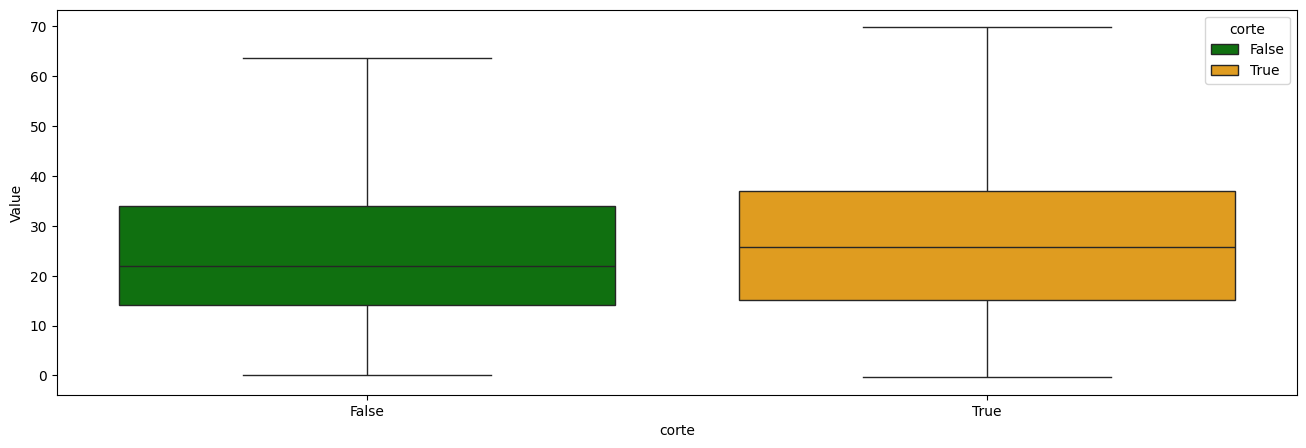

In [7]:
# --- 1. Definir fecha de corte ---
fecha_corte = '2020-04-08 00:00:00'
fecha_corte_dt = pd.to_datetime(fecha_corte)


df_con_cortes = df_sensores.copy()
df_con_cortes['corte'] = df_con_cortes['Timestamp'] >= fecha_corte_dt

df_sensores_sin_118 = df_sensores[df_sensores['Sensor-id'] != 118].copy()


plt.figure(figsize=(16, 5))
ax = sns.boxplot(data=df_con_cortes, x='corte', y='Value', hue='corte', palette=['green','orange'], showfliers=False)

# ax.set_ylim(0,100)
plt.show()
plt.close()

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
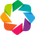

Column(sizing_mode='fixed')
    [0] ParamFunction(function, _pane=HoloViews, defer_load=False)
    [1] Select(label='Seleccionar G..., name='Seleccionar G..., options={'Sensores Fijos (< 100)':...}, value=['1', '4', '6', ...])

In [24]:


# Activar el backend de Bokeh para HoloViews
# Ignorar advertencias molestas de Bokeh
warnings.filterwarnings("ignore", category=BokehUserWarning)

hv.extension('bokeh')
pn.extension()

# --- 1. Preparar datos y definir corte temporal ---
fecha_corte = '2020-04-08 00:00:00'
fecha_corte_dt = pd.to_datetime(fecha_corte)

df_con_cortes = df_sensores.copy()
df_con_cortes['corte'] = df_con_cortes['Timestamp'] < fecha_corte_dt

# Convertir ID a string para asegurar que HoloViews lo trate como categoría en el eje X
df_con_cortes['Sensor-id'] = df_con_cortes['Sensor-id'].astype(str)
df_con_cortes['Periodo'] = np.where(df_con_cortes['corte'], 'Pre', 'Post')

# --- 2. Separar e identificar los IDs de sensores ---
all_sensors_numeric = sorted(df_sensores['Sensor-id'].unique())
fijos = [str(s) for s in all_sensors_numeric if s < 100]
moviles = [str(s) for s in all_sensors_numeric if s >= 100]

# Dividir los móviles en subgrupos de a 10
tamaño_grupo = 10
grupos_moviles = [moviles[i:i + tamaño_grupo] for i in range(0, len(moviles), tamaño_grupo)]

# Generar el diccionario de opciones para el selector
opciones_grupos = {"Sensores Fijos (< 100)": fijos}
for g in grupos_moviles:
    nombre_g = f"Móviles {g[0]}-{g[-1]}"
    opciones_grupos[nombre_g] = g

# --- 3. Definir el Selector Interactivo de Panel ---
selector_grupo = pn.widgets.Select(
    name='Seleccionar Grupo de Sensores',
    options=opciones_grupos,
    width=300
)

# --- 4. Función Reactiva para construir el BoxPlot ---
@pn.depends(selector_grupo.param.value)
def crear_boxplot(sensores_seleccionados):
    # Filtrar datos por los sensores del grupo actual
    df_sub = df_con_cortes[df_con_cortes['Sensor-id'].isin(sensores_seleccionados)]

    # --- Definir la Dimensión del Periodo con Orden Explícito ---
    # Al pasar values=['Pre', 'Post'], forzamos a HoloViews a mantener este orden en el eje X
    dim_periodo = hv.Dimension('Periodo', values=['Pre', 'Post'])

    # Declarar el BoxPlot
    # Al pasar 'Periodo' en kdims junto con 'Sensor-id', HoloViews agrupa los boxes
    boxplot = hv.BoxWhisker(
        df_sub,
        kdims=['Sensor-id', dim_periodo],
        vdims='Value'
    )

    # Opciones de estilo y comportamiento del gráfico
    boxplot.opts(
        # title="Distribución de Radiación por Sensor",
        xlabel="ID del Sensor",
        ylabel="Valor (cpm)",
        ylim=(0, 100),

        # --- Desactivar barra de herramientas (Zoom, Pan, etc.) ---
        default_tools=[],             # <--- Esta línea oculta por completo la barra de Bokeh

        # --- Configuración de la Leyenda ---
        show_legend=False,
        legend_position='bottom',      # <--- Mueve la leyenda abajo del gráfico (fuera del eje X)
        legend_cols=2,                # <--- Distribuye los 2 elementos lado a lado (horizontal)

        # --- Colores por Periodo (solo 2 elementos en la leyenda) ---
        box_color='Periodo',
        cmap=['#2ca02c', '#ff7f0e'],  # Verde para Pre, Naranja para Post

        # --- Dimensiones y Renderizado ---
        width=850,
        height=400,
        shared_axes=False,
        box_fill_alpha=0.7,
        outlier_alpha=0.0            # Oculta los outliers (equivalente a showfliers=False)
    )
    return boxplot

# --- 5. Diseñar la Estructura del Panel ---
dashboard = pn.Column(
    # pn.pane.Markdown("### Dashboard Interactivo de Análisis de Radiación"),

    crear_boxplot,
    selector_grupo,
    sizing_mode='fixed'
)



# --- 6. Guardar como HTML Autónomo ---
dashboard.save(
    'boxplot_interactivo_sensores.html',
    embed=True,
    max_states=10,
    max_opts=15
)

# Mostrar localmente en tu Jupyter Notebook
dashboard.servable()

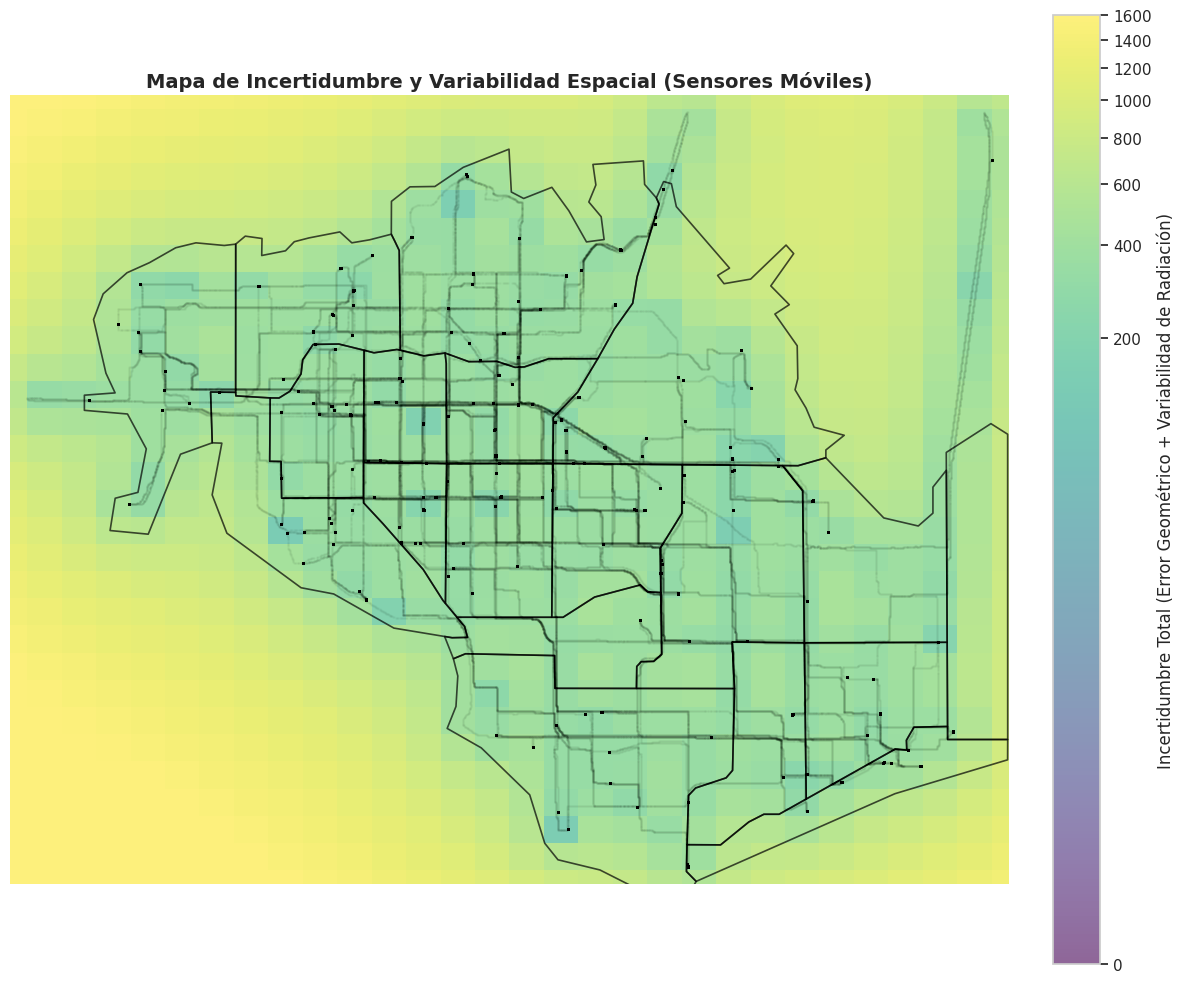

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

def graficar_incertidumbre_sensores_moviles(df, neighborhoods=None, grid_res=150, margen=0.005, alpha=0.6):
    """
    Calcula la incertidumbre de sensores móviles en una grilla estática,
    capturando la variabilidad temporal y espacial de las trayectorias.
    """
    # Copiamos el dataframe para no alterar el original
    df = df.copy()

    # --- 1. DEFINICIÓN DE LA GRILLA COMPARTIDA ---
    x_min, x_max = df['Long'].min() - margen, df['Long'].max() + margen
    y_min, y_max = df['Lat'].min() - margen, df['Lat'].max() + margen

    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)

    # --- 2. CAPTURAR LA VARIABILIDAD EN EL ESPACIO (Spatial Binning) ---
    # En lugar de agrupar por Sensor-ID, agrupamos por "micro-regiones" en el mapa.
    # Esto nos dice cuántas lecturas hubo en cada lugar y qué tan variables fueron.

    # Redondeamos las coordenadas de las trayectorias a los pasos de la grilla
    df['grid_lon'] = pd.cut(df['Long'], bins=x_grid, labels=False, include_lowest=True)
    df['grid_lat'] = pd.cut(df['Lat'], bins=y_grid, labels=False, include_lowest=True)

    # Agrupamos por celda visitada para calcular su promedio y la desviación estándar de las mediciones
    # que ocurrieron ahí a lo largo del tiempo.
    df_celdas = df.groupby(['grid_lon', 'grid_lat']).agg(
        Long_centro=('Long', 'mean'),
        Lat_centro=('Lat', 'mean'),
        Valor_promedio=('Value', 'mean'),
        Varianza_mediciones=('Value', 'var'), # Variabilidad de la radiación en ese punto
        Conteo=('Value', 'count')
    ).reset_index().dropna()

    # Si una celda se visitó pocas veces, su varianza muestral puede ser inestable;
    # le asignamos una base o filtramos si prefieres.
    df_celdas['Varianza_mediciones'] = df_celdas['Varianza_mediciones'].fillna(df_celdas['Valor_promedio'] * 0.1)

    # Extraemos los puntos para Kriging (ahora representan los puntos de la trayectoria resumidos)
    x_puntos = df_celdas['Long_centro'].values
    y_puntos = df_celdas['Lat_centro'].values
    z_puntos = df_celdas['Valor_promedio'].values

    # --- 3. MODELADO DE INCERTIDUMBRE CON KRIGING ---
    # El Kriging toma la distribución espacial de estos promedios móviles
    ok = OrdinaryKriging(
        x_puntos, y_puntos, z_puntos,
        variogram_model='linear',
        verbose=False,
        enable_plotting=False
    )

    # Ejecutamos el Kriging en la grilla completa
    # varianza_distancia nos da el error por falta de cobertura geométrica (distancia a las trayectorias)
    _, varianza_distancia = ok.execute('grid', x_grid, y_grid)

    # Combinamos la incertidumbre geométrica (distancia) con la variabilidad de los datos medidos.
    # Pasamos a desviación estándar (raíz cuadrada)
    incertidumbre_geometrica = np.sqrt(varianza_distancia)

    # Para mapear la variabilidad observada a la grilla, hacemos una interpolación rápida de la varianza medida
    ok_var = OrdinaryKriging(
        x_puntos, y_puntos, df_celdas['Varianza_mediciones'].values,
        variogram_model='linear', verbose=False
    )
    _, variabilidad_medida = ok_var.execute('grid', x_grid, y_grid)
    variabilidad_medida = np.sqrt(np.clip(variabilidad_medida, 0, None))

    # La incertidumbre total es la combinación del error espacial + la variabilidad de la radiación
    incertidumbre_total = incertidumbre_geometrica + variabilidad_medida

    gamma=0.2
    norm_fija = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=1600)

    # --- 4. PLOT ---
    fig, ax = plt.subplots(figsize=(12, 10))

    # Pintamos la grilla de incertidumbre total usando viridis con transparencia
    mesh = ax.pcolormesh(X, Y, incertidumbre_total, shading='auto', cmap='viridis',norm=norm_fija, alpha=alpha)

    cbar = plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Incertidumbre Total (Error Geométrico + Variabilidad de Radiación)', fontsize=12)

    # Dibujamos barrios si existen
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2, alpha=0.7)

    # Dibujamos una muestra de la trayectoria real (puntos grises transparentes de fondo)
    # para ver por dónde pasaron los sensores efectivamente.
    ax.scatter(df['Long'], df['Lat'], color='black', s=1, alpha=0.02, label='Trayectorias Sensores')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title('Mapa de Incertidumbre y Variabilidad Espacial (Sensores Móviles)', fontsize=14, fontweight='bold')
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
    plt.close()

    return None # X, Y, incertidumbre_total

graficar_incertidumbre_sensores_moviles(df_pre, neighborhoods=neighborhoods, grid_res=30, margen=0.005, alpha=0.6)

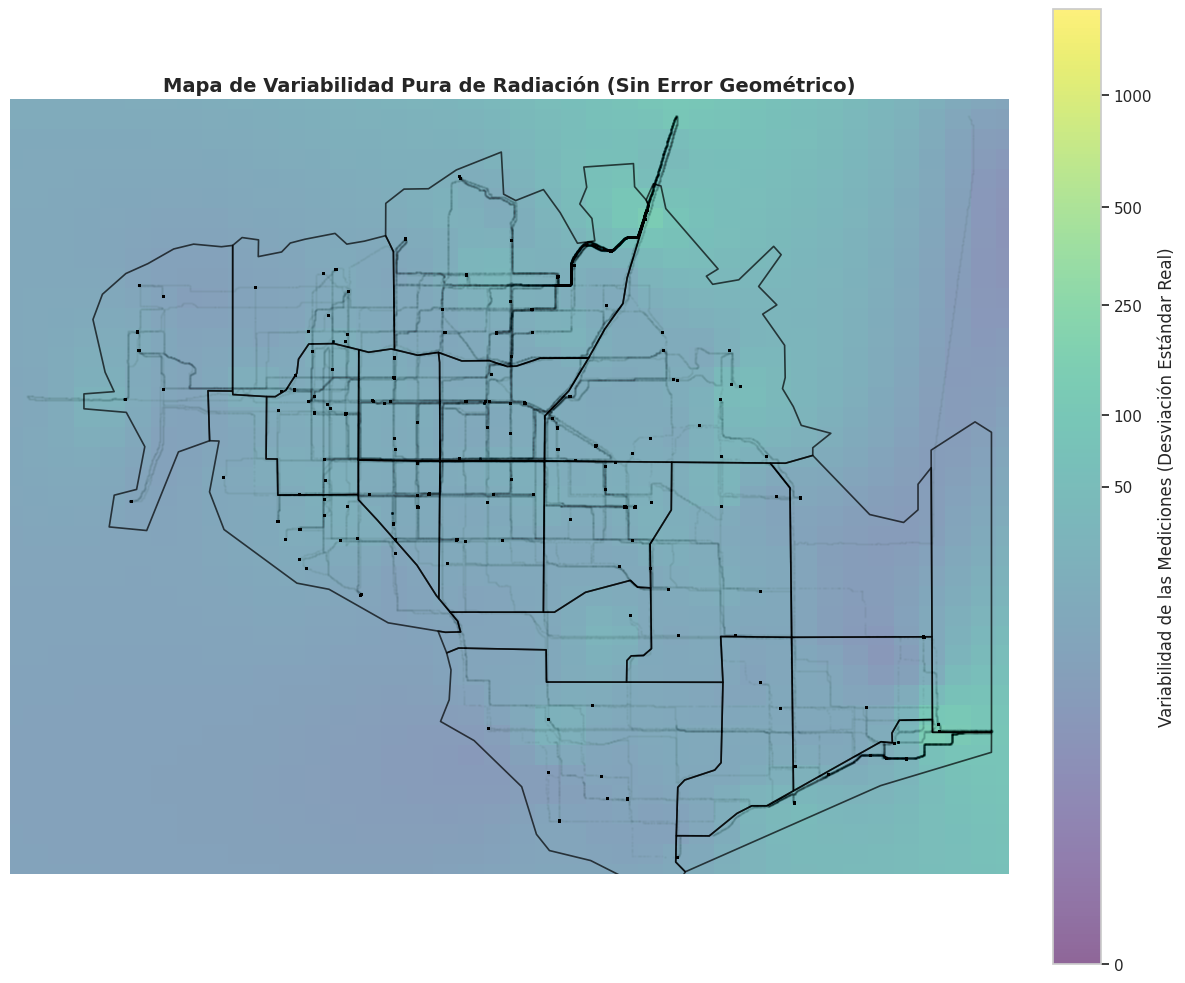

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pykrige.ok import OrdinaryKriging

def graficar_variabilidad_pura_escala_fija(df, neighborhoods=None, grid_res=150, margen=0.005,
                                           alpha=0.6, vmax_fijo=2500, gamma=0.4):
    """
    Calcula y grafica EXCLUSIVAMENTE la variabilidad de las lecturas de los sensores.
    Se elimina la incertidumbre geométrica por distancia.
    """
    df = df.copy()

    # --- 1. GRILLA COMPARTIDA ---
    x_min, x_max = df['Long'].min() - margen, df['Long'].max() + margen
    y_min, y_max = df['Lat'].min() - margen, df['Lat'].max() + margen

    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)

    # --- 2. BINNING ESPACIAL ---
    # Agrupamos los datos móviles en celdas para medir cuánta variación sufren los valores
    df['grid_lon'] = pd.cut(df['Long'], bins=x_grid, labels=False, include_lowest=True)
    df['grid_lat'] = pd.cut(df['Lat'], bins=y_grid, labels=False, include_lowest=True)

    # Calculamos la varianza muestral directamente en cada celda
    df_celdas = df.groupby(['grid_lon', 'grid_lat']).agg(
        Long_centro=('Long', 'mean'),
        Lat_centro=('Lat', 'mean'),
        Varianza_mediciones=('Value', 'var')
    ).reset_index().dropna()

    # Convertimos la varianza a Desviación Estándar (mismas unidades de la radiación)
    df_celdas['DesvEst_mediciones'] = np.sqrt(df_celdas['Varianza_mediciones'])

    x_puntos = df_celdas['Long_centro'].values
    y_puntos = df_celdas['Lat_centro'].values
    z_variabilidad = df_celdas['DesvEst_mediciones'].values

    # --- 3. INTERPOLACIÓN DE LA VARIABILIDAD PURA ---
    # Usamos Kriging únicamente como interpolador para suavizar el mapa entre trayectorias,
    # descartando su matriz de error (la incertidumbre geométrica).
    ok_var = OrdinaryKriging(
        x_puntos, y_puntos, z_variabilidad,
        variogram_model='linear',
        verbose=False,
        enable_plotting=False
    )

    # Extraemos solo el primer valor devuelto (la predicción de la variabilidad)
    # y descartamos el segundo (que contiene la varianza del error geométrico)
    variabilidad_interpolada, _ = ok_var.execute('grid', x_grid, y_grid)

    # Aseguramos que no queden valores negativos por artefactos de la interpolación
    variabilidad_final = np.clip(variabilidad_interpolada, 0, None)

    # --- 4. CONFIGURACIÓN DE LA ESCALA FIJA ---
    norm_fija = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=vmax_fijo)

    # --- 5. PLOT ---
    fig, ax = plt.subplots(figsize=(12, 10))

    # Pintamos el mapa con la escala congelada de 0 a 2500
    mesh = ax.pcolormesh(X, Y, variabilidad_final, shading='auto', cmap='viridis', norm=norm_fija, alpha=alpha)

    ticks_referencia = [0, 50, 100, 250, 500, 1000, 1800, 2500]
    cbar = plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04, ticks=ticks_referencia)
    cbar.set_label('Variabilidad de las Mediciones (Desviación Estándar Real)', fontsize=12)

    # Elementos geográficos y trayectorias de referencia
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2, alpha=0.7)

    ax.scatter(df['Long'], df['Lat'], color='black', s=1, alpha=0.01, label='Trayectorias')

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title('Mapa de Variabilidad Pura de Radiación (Sin Error Geométrico)', fontsize=14, fontweight='bold')
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
    plt.close()

    return None # X, Y, variabilidad_final


graficar_variabilidad_pura_escala_fija(df_post, neighborhoods=neighborhoods, grid_res=40, margen=0.005, alpha=0.6, vmax_fijo=1600, gamma=0.2)

Imagen guardada con éxito en: Variacion_en_mediciones.png (850x500 px)


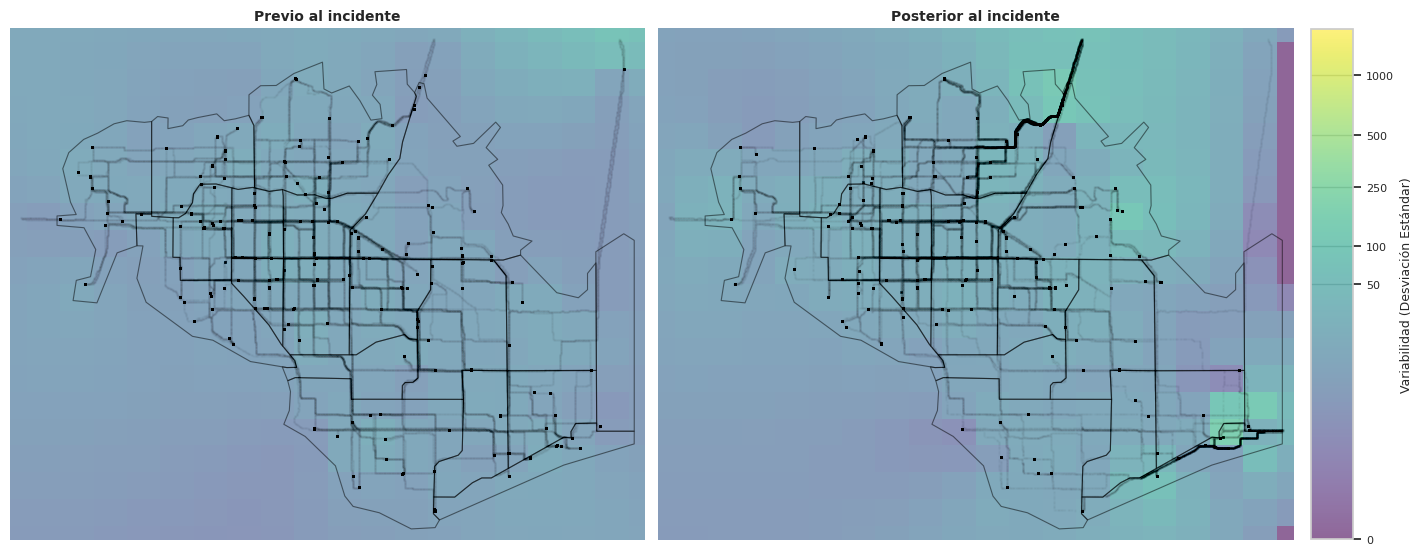

In [102]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pykrige.ok import OrdinaryKriging

def graficar_comparativa_variabilidad(df, neighborhoods=None, grid_res=150, margen=0.005,
                                      alpha=0.6, vmax_fijo=2500, gamma=0.4,
                                      guardar_ruta=None):
    """
    Genera una figura de 850x500 px con dos mapas de variabilidad pura (Antes y Después),
    lado a lado, compartiendo una escala de color fija a la derecha.
    Permite fijar los límites usando los datos globales de sensores y de los barrios.
    """
    df = df.copy()

    # --- 1. DEFINICIÓN DE LÍMITES GEOGRÁFICOS TOTALES ---
    # Extraemos límites de los sensores
    lon_min_s, lon_max_s = df['Long'].min(), df['Long'].max()
    lat_min_s, lat_max_s = df['Lat'].min(), df['Lat'].max()

    # Extraemos límites de los barrios si existen
    if neighborhoods is not None:
        lon_min_n, lat_min_n, lon_max_n, lat_max_n = neighborhoods.total_bounds
        # Nos quedamos con los extremos absolutos combinados
        x_min = min(lon_min_s, lon_min_n) - margen
        x_max = max(lon_max_s, lon_max_n) + margen
        y_min = min(lat_min_s, lat_min_n) - margen
        y_max = max(lat_max_s, lat_max_n) + margen
    else:
        x_min, x_max = lon_min_s - margen, lon_max_s + margen
        y_min, y_max = lat_min_s - margen, lat_max_s + margen

    # Grilla espacial base compartida
    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)

    # --- 2. DIVISIÓN DEL DATAFRAME POR FECHA DE CORTE ---
    fecha_corte_dt = pd.to_datetime('2020-04-08 00:00:00')
    df['antes_corte'] = df['Timestamp'] < fecha_corte_dt

    df_antes = df[df['antes_corte'] == True].copy()
    df_despues = df[df['antes_corte'] == False].copy()

    # --- 3. FUNCIÓN INTERNA PARA INTERPOLAR VARIABILIDAD PURA ---
    def calcular_matriz_variabilidad(df_subset):
        if df_subset.empty:
            return np.zeros(X.shape)

        df_subset['grid_lon'] = pd.cut(df_subset['Long'], bins=x_grid, labels=False, include_lowest=True)
        df_subset['grid_lat'] = pd.cut(df_subset['Lat'], bins=y_grid, labels=False, include_lowest=True)

        df_celdas = df_subset.groupby(['grid_lon', 'grid_lat']).agg(
            Long_centro=('Long', 'mean'),
            Lat_centro=('Lat', 'mean'),
            Varianza_mediciones=('Value', 'var')
        ).reset_index().dropna()

        if df_celdas.empty:
            return np.zeros(X.shape)

        z_variabilidad = np.sqrt(df_celdas['Varianza_mediciones'].values)

        ok_var = OrdinaryKriging(
            df_celdas['Long_centro'].values,
            df_celdas['Lat_centro'].values,
            z_variabilidad,
            variogram_model='linear', verbose=False, enable_plotting=False
        )
        variabilidad_interp, _ = ok_var.execute('grid', x_grid, y_grid)
        return np.clip(variabilidad_interp, 0, None)

    # Calculamos matrices para ambos subconjuntos
    var_antes = calcular_matriz_variabilidad(df_antes)
    var_despues = calcular_matriz_variabilidad(df_despues)

    # --- 4. CONFIGURACIÓN DEL LIENZO (850x500 píxeles usando figsize y DPI) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 10), sharex=True, sharey=True)
    norm_fija = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=vmax_fijo)

    # --- 5. GRÁFICO PANEL IZQUIERDO: ANTES ---
    mesh1 = ax1.pcolormesh(X, Y, var_antes, shading='auto', cmap='viridis', norm=norm_fija, alpha=alpha)
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.5)
    ax1.scatter(df_antes['Long'], df_antes['Lat'], color='black', s=0.5, alpha=0.01)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_title('Previo al incidente', fontsize=10, fontweight='bold')
    ax1.set_axis_off()

    # --- 6. GRÁFICO PANEL DERECHO: DESPUÉS ---
    mesh2 = ax2.pcolormesh(X, Y, var_despues, shading='auto', cmap='viridis', norm=norm_fija, alpha=alpha)
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.5)
    ax2.scatter(df_despues['Long'], df_despues['Lat'], color='black', s=0.5, alpha=0.01)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_title('Posterior al incidente', fontsize=10, fontweight='bold')
    ax2.set_axis_off()

    # --- 7. BARRA DE COLOR ÚNICA A LA DERECHA ---
    # Reducimos un poco el espacio de los subplots para encajar la barra elegantemente
    fig.subplots_adjust(right=0.88, wspace=0.02)
    cbar_ax = fig.add_axes([0.89, 0.24, 0.025, 0.51]) # [left, bottom, width, height]

    ticks_referencia = [0, 50, 100, 250, 500, 1000, 1800, 2500]
    cbar = fig.colorbar(mesh2, cax=cbar_ax, ticks=ticks_referencia)
    cbar.set_label('Variabilidad (Desviación Estándar)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    # --- 8. GUARDAR / MOSTRAR ---
    if guardar_ruta:
        # Forzamos dpi=100 para que coincida exactamente con 850x500 píxeles
        plt.savefig(guardar_ruta, dpi=100, bbox_inches=None)
        print(f"Imagen guardada con éxito en: {guardar_ruta} (850x500 px)")

    plt.show()
    plt.close()

    return None # var_antes, var_despues


graficar_comparativa_variabilidad(df_sensores_sin_118, neighborhoods=neighborhoods, grid_res=20, margen=0.005,
                                      alpha=0.6, vmax_fijo=1600, gamma=0.2,
                                      guardar_ruta='Variacion_en_mediciones.png')

Imagen de incertidumbre guardada en: Variacion_en_mediciones_con_distancia.png (850x500 px)


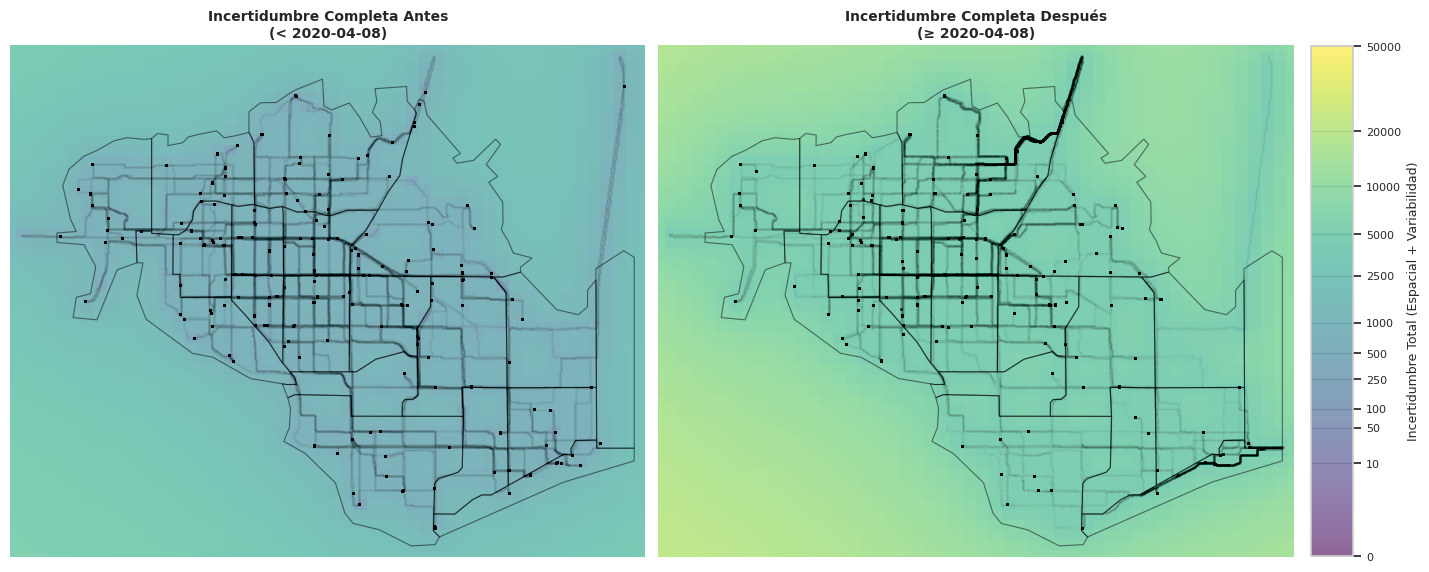

In [98]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pykrige.ok import OrdinaryKriging

def graficar_comparativa_incertidumbre_completa(df, neighborhoods=None, grid_res=150, margen=0.005,
                                                alpha=0.6, vmax_fijo=2500, gamma=0.4,
                                                guardar_ruta=None):
    """
    Genera una figura de 850x500 px con dos mapas de INCERTIDUMBRE COMPLETA (Antes y Después),
    lado a lado, sumando el error de cobertura (espacial) y la variabilidad de las lecturas.
    """
    df = df.copy()

    # --- 1. DEFINICIÓN DE LÍMITES GEOGRÁFICOS TOTALES ---
    lon_min_s, lon_max_s = df['Long'].min(), df['Long'].max()
    lat_min_s, lat_max_s = df['Lat'].min(), df['Lat'].max()

    if neighborhoods is not None:
        lon_min_n, lat_min_n, lon_max_n, lat_max_n = neighborhoods.total_bounds
        x_min = min(lon_min_s, lon_min_n) - margen
        x_max = max(lon_max_s, lon_max_n) + margen
        y_min = min(lat_min_s, lat_min_n) - margen
        y_max = max(lat_max_s, lat_max_n) + margen
    else:
        x_min, x_max = lon_min_s - margen, lon_max_s + margen
        y_min, y_max = lat_min_s - margen, lat_max_s + margen

    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)

    # --- 2. DIVISIÓN POR FECHA DE CORTE ---
    fecha_corte_dt = pd.to_datetime('2020-04-08 00:00:00')
    df['antes_corte'] = df['Timestamp'] < fecha_corte_dt

    df_antes = df[df['antes_corte'] == True].copy()
    df_despues = df[df['antes_corte'] == False].copy()

    # --- 3. FUNCIÓN INTERNA PARA INTERPOLAR INCERTIDUMBRE COMPLETA ---
    def calcular_incertidumbre_completa(df_subset):
        if df_subset.empty:
            return np.zeros(X.shape)

        df_subset['grid_lon'] = pd.cut(df_subset['Long'], bins=x_grid, labels=False, include_lowest=True)
        df_subset['grid_lat'] = pd.cut(df_subset['Lat'], bins=y_grid, labels=False, include_lowest=True)

        df_celdas = df_subset.groupby(['grid_lon', 'grid_lat']).agg(
            Long_centro=('Long', 'mean'),
            Lat_centro=('Lat', 'mean'),
            Valor_promedio=('Value', 'mean'),
            Varianza_mediciones=('Value', 'var')
        ).reset_index().dropna()

        if df_celdas.empty:
            return np.zeros(X.shape)

        # Rellenar varianzas nulas de celdas con una sola lectura para estabilidad del Kriging
        df_celdas['Varianza_mediciones'] = df_celdas['Varianza_mediciones'].fillna(df_celdas['Valor_promedio'] * 0.1)

        x_p = df_celdas['Long_centro'].values
        y_p = df_celdas['Lat_centro'].values
        z_p = df_celdas['Valor_promedio'].values
        z_var = df_celdas['Varianza_mediciones'].values

        # Kriging 1: Obtener la incertidumbre espacial por distancia (Error Geométrico)
        ok_geo = OrdinaryKriging(x_p, y_p, z_p, variogram_model='linear', verbose=False, enable_plotting=False)
        _, varianza_distancia = ok_geo.execute('grid', x_grid, y_grid)
        incertidumbre_geometrica = np.sqrt(np.clip(varianza_distancia, 0, None))

        # Kriging 2: Propagar e interpolar la variabilidad registrada por los sensores móviles
        ok_var = OrdinaryKriging(x_p, y_p, z_var, variogram_model='linear', verbose=False, enable_plotting=False)
        _, variabilidad_medida = ok_var.execute('grid', x_grid, y_grid)
        variabilidad_medida = np.sqrt(np.clip(variabilidad_medida, 0, None))

        # Incertidumbre Completa = Varianza espacial + Desviación estándar de mediciones
        return incertidumbre_geometrica + variabilidad_medida

    # Calculamos matrices para ambos bloques temporales
    inc_antes = calcular_incertidumbre_completa(df_antes)
    inc_despues = calcular_incertidumbre_completa(df_despues)

    # --- 4. CONFIGURACIÓN DEL LIENZO (850x500 píxeles) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 10), sharex=True, sharey=True)
    norm_fija = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=vmax_fijo)

    # --- 5. PANEL IZQUIERDO: ANTES (Kriging Completo) ---
    mesh1 = ax1.pcolormesh(X, Y, inc_antes, shading='auto', cmap='viridis', norm=norm_fija, alpha=alpha)
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.5)
    ax1.scatter(df_antes['Long'], df_antes['Lat'], color='black', s=0.5, alpha=0.01)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_title('Incertidumbre Completa Antes\n(< 2020-04-08)', fontsize=10, fontweight='bold')
    ax1.set_axis_off()

    # --- 6. PANEL DERECHO: DESPUÉS (Kriging Completo) ---
    mesh2 = ax2.pcolormesh(X, Y, inc_despues, shading='auto', cmap='viridis', norm=norm_fija, alpha=alpha)
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.5)
    ax2.scatter(df_despues['Long'], df_despues['Lat'], color='black', s=0.5, alpha=0.01)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_title('Incertidumbre Completa Después\n(≥ 2020-04-08)', fontsize=10, fontweight='bold')
    ax2.set_axis_off()

    # --- 7. BARRA DE COLOR ÚNICA A LA DERECHA ---
    fig.subplots_adjust(right=0.88, wspace=0.02)
    cbar_ax = fig.add_axes([0.89, 0.24, 0.025, 0.51])

    ticks_referencia = [0, 10, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000, 50000]
    cbar = fig.colorbar(mesh2, cax=cbar_ax, ticks=ticks_referencia)
    cbar.set_label('Incertidumbre Total (Espacial + Variabilidad)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)


    # --- 8. GUARDAR / MOSTRAR ---
    if guardar_ruta:
        plt.savefig(guardar_ruta, dpi=100, bbox_inches=None)
        print(f"Imagen de incertidumbre guardada en: {guardar_ruta} (850x500 px)")

    plt.show()
    plt.close()

    return None # inc_antes, inc_despues

graficar_comparativa_incertidumbre_completa(df_sensores_sin_118, neighborhoods=neighborhoods, grid_res=20, margen=0.005,
                                            alpha=0.6, vmax_fijo=50000, gamma=0.2,
                                            guardar_ruta='Variacion_en_mediciones_con_distancia.png')

Mapa comparativo de radiación guardado en: radiacion_valores


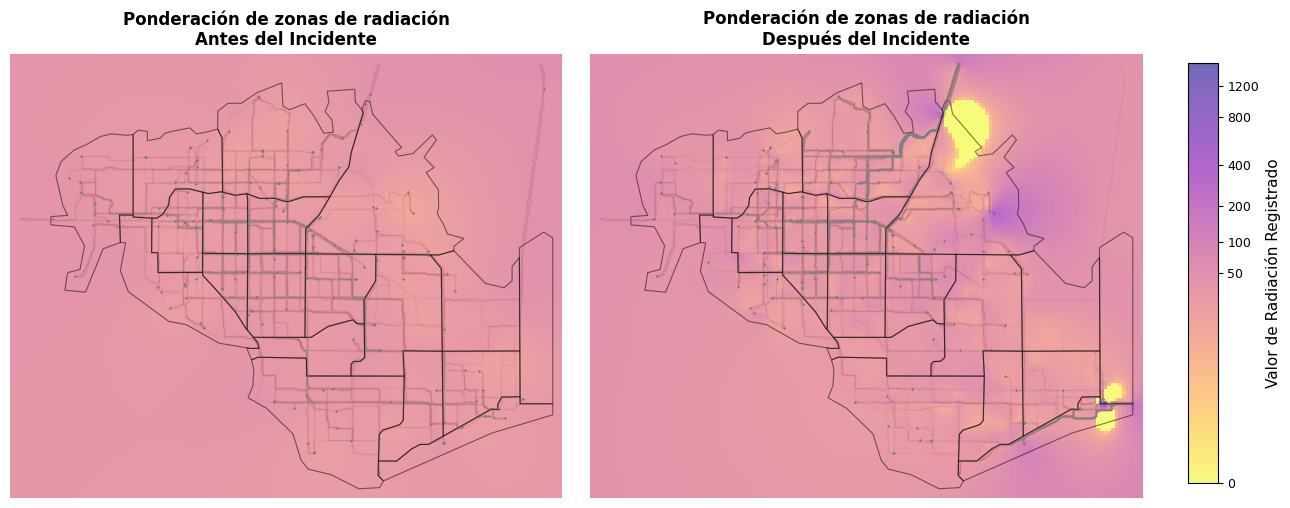

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pykrige.ok import OrdinaryKriging

def graficar_comparativa_radiacion(df, neighborhoods=None, grid_res=150, margen=0.005,
                                   alpha=0.6, vmax_fijo=2500, gamma=0.4,
                                   guardar_ruta=None):
    """
    Genera una figura de 15x6 con dos mapas de valores estimados de RADIACIÓN,
    lado a lado (Antes y Después del incidente), compartiendo una escala fija a la derecha.
    """
    df = df.copy()

    # --- 1. DEFINICIÓN DE LÍMITES GEOGRÁFICOS TOTALES ---
    lon_min_s, lon_max_s = df['Long'].min(), df['Long'].max()
    lat_min_s, lat_max_s = df['Lat'].min(), df['Lat'].max()

    if neighborhoods is not None:
        lon_min_n, lat_min_n, lon_max_n, lat_max_n = neighborhoods.total_bounds
        x_min = min(lon_min_s, lon_min_n) - margen
        x_max = max(lon_max_s, lon_max_n) + margen
        y_min = min(lat_min_s, lat_min_n) - margen
        y_max = max(lat_max_s, lat_max_n) + margen
    else:
        x_min, x_max = lon_min_s - margen, lon_max_s + margen
        y_min, y_max = lat_min_s - margen, lat_max_s + margen

    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)

    # --- 2. DIVISIÓN POR FECHA DE CORTE (INCIDENTE) ---
    fecha_corte_dt = pd.to_datetime('2020-04-08 00:00:00')
    df['antes_corte'] = df['Timestamp'] < fecha_corte_dt

    df_antes = df[df['antes_corte'] == True].copy()
    df_despues = df[df['antes_corte'] == False].copy()

    # --- 3. FUNCIÓN INTERNA PARA INTERPOLAR VALORES DE RADIACIÓN ---
    def calcular_mapa_radiacion(df_subset):
        if df_subset.empty:
            return np.zeros(X.shape)

        # Redondeo espacial (Binning) para agrupar trayectorias densas en celdas de la grilla
        df_subset['grid_lon'] = pd.cut(df_subset['Long'], bins=x_grid, labels=False, include_lowest=True)
        df_subset['grid_lat'] = pd.cut(df_subset['Lat'], bins=y_grid, labels=False, include_lowest=True)

        # Calculamos el promedio de radiación registrado en cada celda visitada
        df_celdas = df_subset.groupby(['grid_lon', 'grid_lat']).agg(
            Long_centro=('Long', 'mean'),
            Lat_centro=('Lat', 'mean'),
            Valor_promedio=('Value', 'mean')
        ).reset_index().dropna()

        if df_celdas.empty:
            return np.zeros(X.shape)

        x_p = df_celdas['Long_centro'].values
        y_p = df_celdas['Lat_centro'].values
        z_p = df_celdas['Valor_promedio'].values

        # Kriging Ordinario para interpolar los valores esperados de radiación
        ok_rad = OrdinaryKriging(x_p, y_p, z_p, variogram_model='linear', verbose=False, enable_plotting=False)

        # Extraemos solo la estimación (descartamos la varianza del error)
        radiacion_interp, _ = ok_rad.execute('grid', x_grid, y_grid)
        return np.clip(radiacion_interp, 0, None)

    # Calculamos los mapas para ambos bloques temporales
    rad_antes = calcular_mapa_radiacion(df_antes)
    rad_despues = calcular_mapa_radiacion(df_despues)

    # --- 4. CONFIGURACIÓN DEL LIENZO (Ampliado a 15x6) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
    norm_fija = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=vmax_fijo)

    # --- 5. PANEL IZQUIERDO: ANTES DEL INCIDENTE ---
    mesh1 = ax1.pcolormesh(X, Y, rad_antes, shading='auto', cmap='plasma_r', norm=norm_fija, alpha=alpha)
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.5)
    ax1.scatter(df_antes['Long'], df_antes['Lat'], color='grey', s=0.25, alpha=0.01)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_title('Ponderación de zonas de radiación\nAntes del Incidente', fontsize=12, fontweight='bold')
    ax1.set_axis_off()

    # --- 6. PANEL DERECHO: DESPUÉS DEL INCIDENTE ---
    # Usamos la misma paleta 'plasma_r' para mantener consistencia con tu mapa original
    mesh2 = ax2.pcolormesh(X, Y, rad_despues, shading='auto', cmap='plasma_r', norm=norm_fija, alpha=alpha)
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=0.8, alpha=0.5)
    ax2.scatter(df_despues['Long'], df_despues['Lat'], color='grey', s=0.25, alpha=0.01)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_title('Ponderación de zonas de radiación\nDespués del Incidente', fontsize=12, fontweight='bold')
    ax2.set_axis_off()

    # --- 7. BARRA DE COLOR ÚNICA A LA DERECHA ---
    fig.subplots_adjust(right=0.88, wspace=0.05)
    cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])

    ticks_referencia = [0, 50, 100, 200, 400, 800, 1200, 1800, 2500]
    cbar = fig.colorbar(mesh2, cax=cbar_ax, ticks=ticks_referencia)
    cbar.set_label('Valor de Radiación Registrado', fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    # --- 8. GUARDAR / MOSTRAR ---
    if guardar_ruta:
        # Al aumentar a 15x6, guardamos con un DPI estándar para respetar la proporción
        plt.savefig(guardar_ruta, dpi=100, bbox_inches='tight', pad_inches=0.1)
        print(f"Mapa comparativo de radiación guardado en: {guardar_ruta}")

    plt.show()
    plt.close()

    return None #rad_antes, rad_despues

graficar_comparativa_radiacion(df_sensores_sin_118, neighborhoods=neighborhoods, grid_res=150, margen=0.005,
                                   alpha=0.6, vmax_fijo=1600, gamma=0.2,
                                   guardar_ruta='radiacion_valores')

Mapa de curvas isométricas guardado en: isometrico_radiacion.png


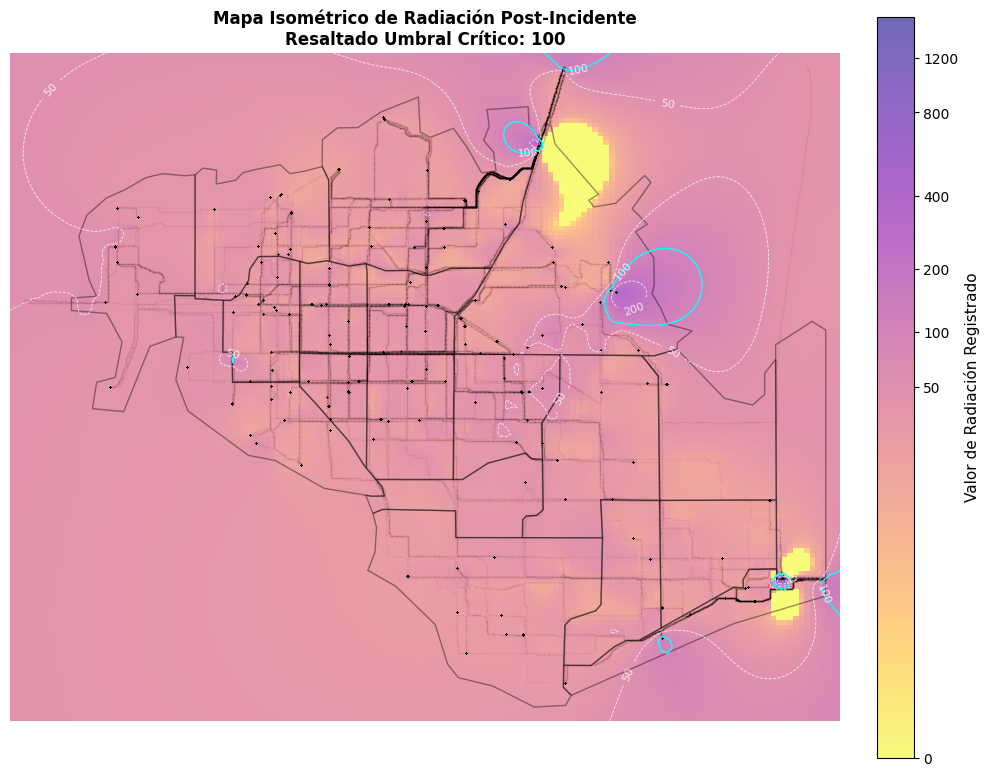

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pykrige.ok import OrdinaryKriging

def graficar_isometrias_post_incidente(df, neighborhoods=None, grid_res=150, margen=0.005,
                                       alpha=0.6, vmax_fijo=2500, gamma=0.4,
                                       umbral=1200, guardar_ruta=None):
    """
    Genera el mapa de radiación posterior al accidente (tamaño optimizado)
    e incorpora líneas isométricas para los ticks de referencia y una línea
    resaltada para el umbral crítico.
    """
    df = df.copy()

    # --- 1. LÍMITES GEOGRÁFICOS TOTALES ---
    lon_min_s, lon_max_s = df['Long'].min(), df['Long'].max()
    lat_min_s, lat_max_s = df['Lat'].min(), df['Lat'].max()

    if neighborhoods is not None:
        lon_min_n, lat_min_n, lon_max_n, lat_max_n = neighborhoods.total_bounds
        x_min = min(lon_min_s, lon_min_n) - margen
        x_max = max(lon_max_s, lon_max_n) + margen
        y_min = min(lat_min_s, lat_min_n) - margen
        y_max = max(lat_max_s, lat_max_n) + margen
    else:
        x_min, x_max = lon_min_s - margen, lon_max_s + margen
        y_min, y_max = lat_min_s - margen, lat_max_s + margen

    x_grid = np.linspace(x_min, x_max, grid_res)
    y_grid = np.linspace(y_min, y_max, grid_res)
    X, Y = np.meshgrid(x_grid, y_grid)

    # --- 2. FILTRAR SOLO POST-ACCIDENTE ---
    fecha_corte_dt = pd.to_datetime('2020-04-08 00:00:00')
    df_despues = df[df['Timestamp'] >= fecha_corte_dt].copy()

    if df_despues.empty:
        print("¡Error: No hay datos posteriores a la fecha de corte seleccionada!")
        return None

    # --- 3. KRIGING DE RADIACIÓN ---
    df_despues['grid_lon'] = pd.cut(df_despues['Long'], bins=x_grid, labels=False, include_lowest=True)
    df_despues['grid_lat'] = pd.cut(df_despues['Lat'], bins=y_grid, labels=False, include_lowest=True)

    df_celdas = df_despues.groupby(['grid_lon', 'grid_lat']).agg(
        Long_centro=('Long', 'mean'),
        Lat_centro=('Lat', 'mean'),
        Valor_promedio=('Value', 'mean')
    ).reset_index().dropna()

    x_p = df_celdas['Long_centro'].values
    y_p = df_celdas['Lat_centro'].values
    z_p = df_celdas['Valor_promedio'].values

    ok_rad = OrdinaryKriging(x_p, y_p, z_p, variogram_model='linear', verbose=False, enable_plotting=False)
    rad_post, _ = ok_rad.execute('grid', x_grid, y_grid)
    rad_post = np.clip(rad_post, 0, None)

    # --- 4. CONFIGURACIÓN DEL LIENZO ---
    # Usamos un tamaño cuadrado/proporcional para un único mapa (ej. 9x8)
    fig, ax = plt.subplots(figsize=(10, 8))
    norm_fija = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=vmax_fijo)

    # Mapa de fondo (Pcolormesh habitual)
    mesh = ax.pcolormesh(X, Y, rad_post, shading='auto', cmap='plasma_r', norm=norm_fija, alpha=alpha)

    # --- 5. LÍNEAS ISOMÉTRICAS (CONTOUR) ---
    ticks_referencia = [0, 50, 100, 200, 400, 800, 1200, 1800, 2500]

    # Filtramos los ticks que estén dentro del rango del mapa para evitar advertencias
    niveles_isometrias = [n for n in ticks_referencia if n > rad_post.min() and n < rad_post.max()]

    # Dibujamos las líneas de referencia generales en un tono gris/blanco sutil
    contornos = ax.contour(X, Y, rad_post, levels=niveles_isometrias,
                           colors='white', linewidths=0.6, alpha=0.8, linestyles='dashed')

    # Añadimos etiquetas numéricas pequeñas sobre las líneas de referencia
    ax.clabel(contornos, inline=True, fontsize=8, fmt='%d', colors='white', )

    # --- 6. FRONTERA DEL UMBRAL CRÍTICO ---
    # Dibujamos específicamente la línea del umbral solicitado si cae dentro del rango
    if rad_post.min() <= umbral <= rad_post.max():
        frontera_critica = ax.contour(X, Y, rad_post, levels=[umbral],
                                      colors='cyan', linewidths=1, linestyles='solid')
        # Etiqueta destacada para la frontera
        ax.clabel(frontera_critica, inline=True, fontsize=10, fmt=f'Frontera: {umbral}', colors='cyan')
    else:
        print(f"Nota: El umbral {umbral} está fuera del rango de datos recalculados ({rad_post.min():.1f} a {rad_post.max():.1f})")

    # --- 7. ELEMENTOS GEOGRÁFICOS ---
    if neighborhoods is not None:
        neighborhoods.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0, alpha=0.4)

    # Trayectoria de fondo muy tenue
    ax.scatter(df_despues['Long'], df_despues['Lat'], color='black', s=0.4, alpha=0.01)

    # Ajustes de formato y Barra de Color
    cbar = plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04, ticks=ticks_referencia)
    cbar.set_label('Valor de Radiación Registrado', fontsize=11)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f'Mapa Isométrico de Radiación Post-Incidente\nResaltado Umbral Crítico: {umbral}', fontsize=12, fontweight='bold')
    ax.set_axis_off()

    plt.tight_layout()

    # --- 8. GUARDAR ---
    if guardar_ruta:
        plt.savefig(guardar_ruta, dpi=120, bbox_inches='tight', pad_inches=0.1)
        print(f"Mapa de curvas isométricas guardado en: {guardar_ruta}")

    plt.show()
    plt.close()
    return None # rad_post

graficar_isometrias_post_incidente(df_sensores_sin_118, neighborhoods=neighborhoods, grid_res=150, margen=0.005,
                                       alpha=0.6, vmax_fijo=1600, gamma=0.2,
                                       umbral=100, guardar_ruta='isometrico_radiacion.png')

In [ ]:
# --- 1. Definir fecha de corte ---
fecha_corte = '2020-04-08 00:00:00'
fecha_corte_dt = pd.to_datetime(fecha_corte)

df_con_cortes = df_sensores.copy()
df_con_cortes['corte'] = df_con_cortes['Timestamp'] >= fecha_corte_dt



# --- 2. Filtrar el DataFrame global (solo lecturas anteriores a la fecha) ---
df_filtrado_fecha_antes = df_sensores[df_sensores['Timestamp'] <= fecha_corte_dt].copy()
df_filtrado_fecha_despues = df_sensores[df_sensores['Timestamp'] >= fecha_corte_dt].copy()

# --- 3. Agrupar por día (cambiar freq a '600min' si se desea) ---
agrupado_por_sensor_antes = df_filtrado_fecha_antes.groupby(pd.Grouper(key='Sensor-id'))
agrupado_por_sensor_despues = df_filtrado_fecha_despues.groupby(pd.Grouper(key='Sensor-id'))

# --- 4. Estadísticas por grupo ---
stats_antes = agrupado_por_sensor_antes['Value'].agg(['min', 'max', 'median', 'mean', 'std']).sort_index()
stats_despues = agrupado_por_sensor_despues['Value'].agg(['min', 'max', 'median', 'mean', 'std']).sort_index()

# Mostrar todas las columnas (sin límite)
pd.set_option('display.max_columns', 1000)

# Ajustar el ancho de la salida al ancho de la terminal (0 = auto)
pd.set_option('display.width', 1000)


### Estadísticas

Quismos evaluar la variabilidad e incertidumbre de las mediciones para los sensores, antes del incidente. Tenienddo como criterio que antes de la primera fuga de radiación generada por el terremoto no deberíamos encontrar valores altos de radiación en ningún sensor. En base al análisis exploratorio realizado previamente sabemos que el incidente tiene lugar después de las 0 horas del 8/4/20.

In [38]:
import pandas as pd
import numpy as np
import holoviews as hv
import panel as pn

# # Activar extensiones
# hv.extension('bokeh')
# pn.extension()

# 1. Filtrar periodo previo al incidente
fecha_corte = pd.to_datetime('2020-04-08 00:00:00')
df_pre = df_sensores[df_sensores['Timestamp'] < fecha_corte].copy()

# 2. Calcular la incertidumbre (Desviación Estándar) por sensor
df_incertidumbre = df_pre.groupby('Sensor-id')['Value'].std().reset_index(name='Incertidumbre (std)')

# 3. Clasificar sensores en Fijos (< 100) y Móviles (>= 100)
df_incertidumbre['Tipo'] = np.where(df_incertidumbre['Sensor-id'] < 100, 'Fijo', 'Móvil')

# Ordenar por ID para la visualización del eje X
df_incertidumbre = df_incertidumbre.sort_values('Sensor-id')
df_incertidumbre['Sensor-id'] = df_incertidumbre['Sensor-id'].astype(str)

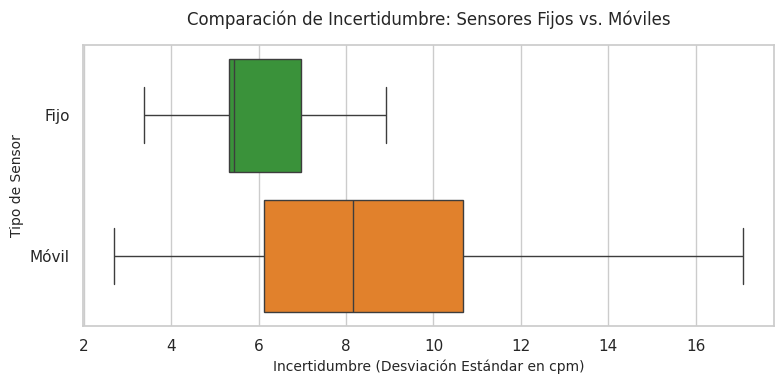

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np



# --- 1. Configurar la resolución y dimensiones del gráfico ---
# 800x400 píxeles a 100 DPI (puntos por pulgada) equivale a 8x4 pulgadas
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)

# --- 2. Configurar el estilo visual (limpio y sin distracciones) ---
sns.set_theme(style="whitegrid")

# --- 3. Generar el Boxplot ---
sns.boxplot(
    data=df_incertidumbre,
    y='Tipo',
    x='Incertidumbre (std)',
    hue='Tipo',                # Mapea los colores por tipo de sensor
    palette=['#2ca02c', '#ff7f0e'], # Tu paleta: Verde (Fijo) y Naranja (Móvil)
    showfliers=False,          # Oculta los outliers para mantenerlo limpio
    ax=ax
)

# --- 4. Personalizar textos y límites ---
ax.set_title("Comparación de Incertidumbre: Sensores Fijos vs. Móviles", fontsize=12, pad=15)
ax.set_ylabel("Tipo de Sensor", fontsize=10)
ax.set_xlabel("Incertidumbre (Desviación Estándar en cpm)", fontsize=10)

# --- 5. Ajustar diseño y mostrar/guardar ---
plt.tight_layout()

# Guardar la imagen optimizada para tu web si lo necesitas:
# plt.savefig('incertidumbre_fijos_vs_moviles.png', dpi=100, bbox_inches='tight')

plt.show()
fig.savefig('incertidumbre_fijos_vs_moviles.png', dpi=100, bbox_inches='tight')
plt.close()

In [ ]:
print("=== Estadísticas por grupo (Sensor) ===")
print(stats_antes.merge(stats_despues, on='Sensor-id', suffixes=('_a', '_d')))

Tomamos de referencia los sensores fijos (*Sensor-id* entre 1-15), que suponemos más precisos y mejor calibrados que los confeccionados por el club de científicos de la ciudad. En base a eso podemos evaluar que la radiación base oscila alrededor de 14.5 cpm. En esto las lecturas de los sensores fijos son coherentes entre si, mientras que para los sensores móviles observamos muchas veces lecturas mayores, hasta casi tres veces en algunos casos.

Para los dos tipos de sensores observamos lecturas elevadas que consideramos errores, dado que no se corresponden con otras lecturas sucesivas. También observamos que las desviaciones estandar son bajas, máximo 17 cpm, en parte debido a la abundancia de datos, pero esto nos a confianza en que podemos tomarlas de referencia para contrastar con las lecturas que superen los 75 cpm durante períodos más prolongados de tiempo.

## 3. Given the uncertainty you observed in question 2, are the radiation measurements reliable enough to locate areas of concern?

    1. Highlight potential locations of contamination, including the locations of contaminated cars. Should St. Himark officials be worried about contaminated cars moving around the city?
    2. Estimate how many cars may have been contaminated when coolant leaked from the Always Safe plant. Use data analysis of radiation measurements to determine if any have left the area.
    3. Indicated where you would deploy more sensors to improve radiation monitoring in the city. Would you recommend more static sensors or more mobile sensors or both? Use your analysis of radiation measurement uncertainty to justify your recommendation.


### Funciones

In [ ]:
def detectar_picos_sostenidos(df, umbral=60, min_consecutivos=4):
    """
    Identifica sensores que reportan valores superiores a un umbral
    durante estrictamente más de 'min_consecutivos' lecturas seguidas.
    """
    # 1. Ordenar por sensor y tiempo para garantizar la secuencia temporal lógica
    df_sorted = df.sort_values(['Sensor-id', 'Timestamp']).copy()

    # 2. Crear máscara booleana para los valores que superan el umbral
    df_sorted['es_elevado'] = df_sorted['Value'] > umbral

    # 3. Identificar bloques consecutivos.
    # Cada vez que 'es_elevado' cambia (de True a False o viceversa),
    # cumsum() suma 1, creando un ID único para cada racha.
    df_sorted['bloque_id'] = (df_sorted['es_elevado'] != df_sorted['es_elevado'].shift()).cumsum()

    # 4. Quedarnos solo con los registros que sí superan el umbral
    df_altos = df_sorted[df_sorted['es_elevado']]

    # 5. Contar cuántos registros consecutivos tiene cada bloque por sensor
    conteos_bloque = df_altos.groupby(['Sensor-id', 'bloque_id']).size().reset_index(name='conteo')

    # 6. Filtrar los bloques que tienen MÁS de 'min_consecutivos' registros
    bloques_anomalos = conteos_bloque[conteos_bloque['conteo'] > min_consecutivos]

    # 7. Cruzar (merge) con el DataFrame ordenado para recuperar toda la info (Lat, Long, etc.)
    df_resultado = df_sorted.merge(bloques_anomalos[['Sensor-id', 'bloque_id']], on=['Sensor-id', 'bloque_id'])

    # Limpiar las columnas auxiliares antes de retornar
    return df_resultado

In [ ]:
import warnings
from bokeh.util.warnings import BokehUserWarning
import panel as pn
import pandas as pd
import seaborn as sns
# Importamos Figure directamente para no usar el backend global 'plt'
from matplotlib.figure import Figure

# Ignorar advertencias molestas de Bokeh
warnings.filterwarnings("ignore", category=BokehUserWarning)

pn.extension()

def plot_panel(df_sensores):
    # Asegurar ordenamiento temporal para el análisis de consecutivos
    df_sorted_base = df_sensores.sort_values(['Sensor-id', 'Timestamp']).copy()

    def plot_interactive(threshold, filter_consecutivos, min_consecutivos):
        df_filt = df_sorted_base.copy()
        df_filt['es_elevado'] = df_filt['Value'] >= threshold

        if filter_consecutivos:
            df_filt['bloque_id'] = (df_filt['es_elevado'] != df_filt['es_elevado'].shift()).cumsum()
            df_altos = df_filt[df_filt['es_elevado']]

            if len(df_altos) > 0:
                conteos_bloque = df_altos.groupby(['Sensor-id', 'bloque_id']).size().reset_index(name='conteo')
                bloques_anomalos = conteos_bloque[conteos_bloque['conteo'] >= min_consecutivos]
                df_filt = df_altos.merge(bloques_anomalos[['Sensor-id', 'bloque_id']], on=['Sensor-id', 'bloque_id'])
            else:
                df_filt = pd.DataFrame(columns=df_filt.columns)
        else:
            df_filt = df_filt[df_filt['es_elevado']].copy()

        # --- API Orientada a Objetos de Matplotlib (Sin plt) ---
        # Esto evita que Matplotlib intente "imprimir" representaciones de texto en el HTML
        fig = Figure(figsize=(14, 5))
        (ax1, ax2) = fig.subplots(1, 2)

        # Validación de datos vacíos
        if len(df_filt) == 0:
            msg = f'No hay lecturas que cumplan los criterios (Umbral >= {threshold})'
            if filter_consecutivos:
                msg += f'\ny con al menos {min_consecutivos} consecutivas.'

            ax1.text(0.5, 0.5, msg, ha='center', va='center', transform=ax1.transAxes, fontsize=10)
            ax2.text(0.5, 0.5, msg, ha='center', va='center', transform=ax2.transAxes, fontsize=10)
            fig.tight_layout()
            return fig

        # Normalización de Timestamp
        t_num = df_filt['Timestamp'].astype('int64') // 10**9
        t_min = t_num.min()
        t_max = t_num.max()
        df_filt['Timestamp_norm'] = (t_num - t_min) / (t_max - t_min) * 4 if t_max > t_min else 0

        # Gráfico 1: Tiempo normalizado vs Sensor
        sns.stripplot(data=df_filt, x='Sensor-id', y='Timestamp_norm',
                      jitter=True, alpha=0.6, size=3, ax=ax1)
        ax1.set_title(f'Distribución temporal (normalizada) - Umbral ≥ {threshold}', fontsize=12, weight='bold')
        ax1.set_xlabel('ID del Sensor', fontsize=10)
        ax1.set_ylabel('Timestamp normalizado (0-4)', fontsize=10)
        ax1.tick_params(axis='x', rotation=90)

        # Gráfico 2: Valor real vs Sensor
        sns.stripplot(data=df_filt, x='Sensor-id', y='Value',
                      jitter=True, alpha=0.4, size=4, ax=ax2)
        ax2.set_title(f'Distribución de valores de radiación - Umbral ≥ {threshold}', fontsize=12, weight='bold')
        ax2.set_xlabel('ID del Sensor', fontsize=10)
        ax2.set_ylabel('Valor (cpm)', fontsize=10)
        ax2.tick_params(axis='x', rotation=90)

        fig.tight_layout()
        return fig

    # --- WIDGETS ---
    max_val = df_sensores['Value'].max()

    slider_umbral = pn.widgets.FloatSlider(
        name='Umbral de filtro (Value ≥)',
        start=50,
        end=150,  # int(max_val),
        step=10,
        value=60,
        width=300
    )

    chk_consecutivos = pn.widgets.Checkbox(
        name='Filtrar solo valores consecutivos altos',
        value=False
    )

    # input_min_consecutivos = pn.widgets.IntInput(
    #     name='Mínimo de consecutivos',
    #     value=2,
    #     start=2,
    #     end=4,
    #     width=150,
    #     disabled=pn.bind(lambda activo: not activo, chk_consecutivos)
    # )

    # Vincular los widgets con la función de gráfico
    interactive_plot = pn.bind(
        plot_interactive,
        threshold=slider_umbral,
        filter_consecutivos=chk_consecutivos,
        min_consecutivos=2
    )

    # --- Estructura del Dashboard ---
    dashboard = pn.Column(
        pn.pane.Markdown("## 🎚️ Filtro interactivo de lecturas de radiación"),
        pn.Row(
            slider_umbral,
            pn.Column(chk_consecutivos),
            pn.Spacer(width=50)
        ),
        # Convertimos la salida del bind en un componente estricto de Matplotlib
        pn.pane.Matplotlib(interactive_plot, dpi=100, tight=True)
    )

    return dashboard

# Generar el dashboard
df_sensores_4to_quantil = df_sensores[df_sensores['Value'] > df_sensores.Value.quantile(0.75)].copy()
dashboard_final = plot_panel(df_sensores_4to_quantil)

# --- EXPORTAR A HTML ---
# Puedes guardar el dashboard directamente como un archivo HTML estático interactivo:
dashboard_final.save('dashboard_radiacion.html', embed=True, max_states=100, max_opts=10)

### Informe

In [ ]:
# --- Ejecución sobre tus datos ---
df_alertas = detectar_picos_sostenidos(df_sensores, umbral=60, min_consecutivos=2)

# Ver resumen de los sensores críticos detectados
sensores_criticos = df_alertas['Sensor-id'].unique()
print(f"⚠️ Se detectaron {len(sensores_criticos)} sensores con alertas sostenidas (>60 por más de 2 registros).")
print(f"IDs de sensores implicados: {sensores_criticos}")

In [ ]:
plot_recorridos(df_alertas, color_por_sensor)

In [ ]:
plot_recorridos_3d_plotly_simple(df_alertas, color_por_sensor, umbral=61, neighborhoods=neighborhoods)

A priori, y dado que las desviaciones de medicion previas al incidente se encuentran en un órden bastánte inferior a los niveles de radiación que esperamos encontrar, no vamos a descartar la información de ningún sensor.

1. Consideramos radiacion alta a una lectura superior a 60 cpm (43 + 17 por el sensor 118). Para filtrar ruido consideramos solo los valores altos cuano hay más de un registro alto consecutivo.

   Tenemos lecturas muy fuertes en la intersección de la Autopista Wilson Forest con la Avenida Hilmark. Luego destaca el recorrido entrer el Hospital de Old Town y el Puente Jade donde más de un sensor movil registra valores por encima de 60.

2. Los sensores moviles 121, 122, 124, 125, 127, 128, 129 y 145 enrtan y salen de una zona altamente contaminada. y puede suponerse que son autos contaminados.
   Lo mismo para el sensor 102, las lecturas promedio antes del incidente de este sensor son de 27 cpm con un desvío estandar de 17, y luego del incidente pasan en promedio a ser de 42, con el mismo desvio. Otro tanto pasa con el 142, de una mediana y promeio de 34 cpm pasan a una mediana y promedio de 52 y 50 cpm.
   

3. Más allá de que no descarté ningún sensor en mi análisis yo intentaría agregar más de los dos tipos de sensores. Colocaría los fijos en los puentes y accesos de la cuidad y trataría que los moviles estuvieran uniformemente distribuidos. en particular considero que para este incidente puntual hubiera side de ayuda tener sensores fijos en el centro de la ciudad, Jade Ave y Cascadia St, y en la zona más despoblada de Pepper Mill, Terraping Springs y Scenic Vista.
   

## 4. Summarize the state of radiation measurements at the end of the available period.
Use your data analysis approaches to suggest a course of action for the city.

Use analytics to compare the static sensor network to the mobile sensor network.
What are the strengths and weaknesses of each approach? How do they support each other?

Según los registros de la mayoría de los sensores, los niveles de radiación de la ciudad permanecen en un nivel más alto que el que había previo al terremoto. Por lo que es seguro que hay que tomer medidas para seguir reduciendolos. En particular prestaría atención a quienes presenten sintomas de radiacion en la zona norte de la cuidad dado que se observan varios registros cercanos a los hospitales. Además revisaría el area de Scenic Vista y la intersección de Autopista Wilson Forest con la Avenida Hilmark.

Entre los sensores mobiles y los fijos tenemos que las fortalezas de los fijos es que además de ser más precisos, tienen el rgistro completo de valores par un mismo lugar lo que hace posible hacer un seguimiento pleno para ese lugar. lo que tiene en contra es su poca cobertura. Los moviles en cambio cubren un área más grande al deplazarse pero una vez que salen del area contaminada dejan de medir con lo que no se sabe si los valores de ese lugar disminuyeron o no hasta que algun otro sensor movil vuelve a pasar. Una Solución intermedia podría ser colocar sensores moviles en el transporte público que garantiza una cobertura extendida y con una actualización frecuente. Uno de los temas de nuestros sensores moviles es que durante la noche no se movían mucho tampoco.

### Heatmap de Alertas por Sensor (Reordenado)

In [ ]:
def heat_read(df_sensores, gamma=0.4, sensor_order=None, time_freq='1min'):
    df = df_sensores.copy()

    # Apply sensor order if provided, otherwise derive it
    if sensor_order is not None:
        df['Sensor-id'] = pd.Categorical(df['Sensor-id'], categories=sensor_order, ordered=True)
    else:
        df['Sensor-id'] = pd.Categorical(df['Sensor-id'], categories=df['Sensor-id'].unique(), ordered=True)

    df = df.sort_values(['Sensor-id', 'Timestamp'])

    fecha_corte = '2020-04-08 00:00:00'
    fecha_corte_dt = pd.to_datetime(fecha_corte)

    # Determine overall time range for the heatmap
    min_overall_time = fecha_corte_dt #df['Timestamp'].min()
    max_overall_time = df['Timestamp'].max()

    # Create a full range of time bins at the specified frequency
    full_time_index = pd.date_range(start=min_overall_time.floor(time_freq),
                                    end=max_overall_time.ceil(time_freq),
                                    freq=time_freq)

    # Aggregate values to the chosen time frequency
    df['TimeBin'] = df['Timestamp'].dt.floor(time_freq)
    df_agg = df.groupby(['Sensor-id', 'TimeBin'], observed=False)['Value'].mean().reset_index()

    # Create pivot table. Reindex columns with the full_time_index to include all time bins
    # and explicitly show gaps as NaN.
    pivot = df_agg.pivot_table(index='Sensor-id', columns='TimeBin', values='Value', observed=False)
    pivot = pivot.reindex(columns=full_time_index) # This will insert columns for empty time bins with NaN

    norm = mcolors.PowerNorm(gamma=gamma, vmin=0, vmax=1200)

    plt.figure(figsize=(16, 12)) # Increased figure width for potentially more columns
    ax = sns.heatmap(pivot, cmap='plasma_r', norm=norm,
                     cbar_kws={'label': 'Value', 'ticks': [0, 50, 100, 200, 400, 800, 1200]},
                     cbar=True,
                     mask=pivot.isnull()) # Mask NaN values to make empty time visible

    # The x-axis labels are still invisible by default. The proportional spacing
    # is handled by the even width of the columns created by reindex.
    ax.axes.get_xaxis().set_visible(False)
    plt.title(f'Heatmap con escala PowerNorm (gamma={gamma}) - Mayor detalle en 0-200 (Frecuencia Temporal: {time_freq})')
    plt.show()
    return None

In [ ]:
fecha_corte = '2020-04-08 00:00:00'
fecha_corte_dt = pd.to_datetime(fecha_corte)

df_alertas_corto = df_alertas[df_alertas['Sensor-id'] != 118 ]
df_alertas_corto = df_alertas_corto[df_alertas_corto['Timestamp'] >= fecha_corte_dt]

In [ ]:
# Create a dictionary mapping each Sensor-id to its *first* Timestamp in the original df_alertas
# This ensures the order is based on the true first appearance across the entire dataset.
dict_para_orden = {}
for sensor_id in df_alertas_corto['Sensor-id'].unique():
    # Find the earliest timestamp for each sensor in the original df_alertas
    first_appearance_time = df_alertas_corto[df_alertas_corto['Sensor-id'] == sensor_id]['Timestamp'].min()
    dict_para_orden[sensor_id] = first_appearance_time

# Create a DataFrame to sort sensors by their first appearance timestamp
df_orden = pd.DataFrame(list(dict_para_orden.items()), columns=['Sensor-id', 'Timestamp']).sort_values('Timestamp')

# Get the list of sensor IDs in the desired order (by first appearance)
sensor_order_list = df_orden['Sensor-id'].tolist()

df_alertas_sorted = df_alertas_corto.copy()

# Convert the 'Sensor-id' column in df_alertas_sorted to a categorical type with the custom order.
# This ensures that when the pivot table is created in heat_read, the index (Sensor-id)
# will follow this specific order.
df_alertas_sorted['Sensor-id'] = pd.Categorical(
    df_alertas_sorted['Sensor-id'], categories=sensor_order_list, ordered=True
)

# Sort the DataFrame again, now by the new categorical 'Sensor-id' and then by 'Timestamp'.
# This ensures that if heat_read relies on the input DataFrame's sort order, it will be correct.
df_alertas_sorted = df_alertas_sorted.sort_values(['Sensor-id', 'Timestamp']).copy()

# Generate the heatmap with the reordered DataFrame, passing the explicit order and a time frequency
heat_read(df_alertas_sorted, gamma=0.4, sensor_order=sensor_order_list, time_freq='20min')

In [ ]:
heat_read(df_sensores, gamma=0.4, sensor_order=sensor_order_list, time_freq='20min')

In [ ]:
df_sensores.Value.describe().round(2)

In [ ]:
(df_sensores.Value.quantile(0.75))